# 虚拟筛选结果分析

目标：从不同打分流程中挑选一批值得进入更高精度复打分的分子。KarmaDock 部分以 `karma_score_aligned` 作为主要排序分数；CarsiDock 和 Glide 后续作为独立或互补证据加入。

当前选择思路：
- 先用 KarmaDock + CarsiDock 联合挑选一批分子，重点看两个 KRAS 突变体上都比较稳定的候选。
- Glide SP G12D 结果单独保留一批 Top 分子，不强行要求与 KarmaDock/CarsiDock 重合。
- 最后把两个候选池去重后送入更高精度、更慢的打分流程。


In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except Exception:
    sns = None
    plt.style.use("default")

%matplotlib inline
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

# Switches: keep these False by default.
EXPORT_TABLES = False
SAVE_FIGURES = False

KARMADOCK_DATA = Path("/mnt/data/KarmaDock/screening_runs/runs")
RUNS = {
    "G12D": KARMADOCK_DATA / "7rpz_sample10k/full_result/score.csv",
    "G12V": KARMADOCK_DATA / "g12v_sample10k_br7/full_result/score.csv",
}
SAMPLE_ID_MAP = Path("/mnt/data/CarsiDock/inputs/karmadock_sample10k/sample10k_id_map.csv")
OUT_DIR = Path("/home/aidd/CarsiDock/analysis_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

PRIMARY_SCORE = "karma_score_aligned"
SCORE_COLS = ["karma_score", "karma_score_ff", "karma_score_aligned"]
TOP_N = 100
TOPK_VALUES = [10, 20, 50, 100, 200, 500, 1000, 2000]
TOP_PERCENT_VALUES = [0.005, 0.01, 0.02, 0.05, 0.10, 0.20]

# Dual-target candidate table sizes.
JOINT_TOP_N = 100


## 读取 KarmaDock 分数

这里读取两个靶点的 `score.csv`，并为每个分数字段计算单靶点排名和百分位。`karma_score_aligned` 后续作为 KarmaDock 的主排序依据。


In [2]:
def load_scores(name, path):
    df = pd.read_csv(path)
    missing = [c for c in ["pdb_id", *SCORE_COLS] if c not in df.columns]
    if missing:
        raise ValueError(f"{path} is missing columns: {missing}")
    df = df[["pdb_id", *SCORE_COLS]].copy()
    df["target"] = name
    for col in SCORE_COLS:
        df[f"rank_{col}"] = df[col].rank(method="first", ascending=False).astype(int)
        # Higher percentile is better. This is more comparable across targets than raw score.
        n = len(df)
        df[f"pct_{col}"] = 1.0 - (df[f"rank_{col}"] - 1) / max(n - 1, 1)
    df["rank_aligned"] = df[f"rank_{PRIMARY_SCORE}"]
    df["pct_aligned"] = df[f"pct_{PRIMARY_SCORE}"]
    return df.sort_values(PRIMARY_SCORE, ascending=False).reset_index(drop=True)

scores = {name: load_scores(name, path) for name, path in RUNS.items()}
for name, df in scores.items():
    print(f"{name}: {df.shape[0]} rows from {RUNS[name]}")
    display(df[["pdb_id", *SCORE_COLS, "rank_aligned", "pct_aligned"]].head(10))


G12D: 9988 rows from /mnt/data/KarmaDock/screening_runs/runs/7rpz_sample10k/full_result/score.csv


,pdb_id,karma_score,karma_score_ff,karma_score_aligned,rank_aligned,pct_aligned
0,sample_7415,45.453091,41.018364,42.169510,1,1.000000
1,sample_5974,35.196850,35.806988,41.730095,2,0.999900
2,sample_4843,34.315937,32.160412,41.668610,3,0.999800
3,sample_6184,35.682884,32.596535,41.599277,4,0.999700
4,sample_2753,33.269436,33.483528,41.564251,5,0.999599
5,sample_3596,43.000031,36.619812,41.531425,6,0.999499
6,sample_5369,45.903881,42.439167,41.446884,7,0.999399
7,sample_7040,35.702087,35.838223,41.364567,8,0.999299
8,sample_6000,47.237347,44.918350,41.120708,9,0.999199
9,sample_9121,34.195942,36.428185,41.109043,10,0.999099


G12V: 9988 rows from /mnt/data/KarmaDock/screening_runs/runs/g12v_sample10k_br7/full_result/score.csv


,pdb_id,karma_score,karma_score_ff,karma_score_aligned,rank_aligned,pct_aligned
0,sample_8482,46.537834,47.055069,50.350502,1,1.000000
1,sample_7273,50.811787,49.830418,50.210110,2,0.999900
2,sample_3416,48.286167,45.701359,49.836140,3,0.999800
3,sample_2994,50.961655,50.119884,49.440201,4,0.999700
4,sample_3916,46.171143,45.085411,49.435192,5,0.999599
5,sample_2743,43.601151,44.923119,49.261501,6,0.999499
6,sample_5138,45.233856,48.871601,48.691044,7,0.999399
7,sample_418,46.451042,44.316139,48.300968,8,0.999299
8,sample_2732,42.881680,42.850903,48.192364,9,0.999199
9,sample_5085,42.861164,42.683075,48.063610,10,0.999099


In [3]:
# Check molecules that were present in the sample map but absent from either result.
if SAMPLE_ID_MAP.exists():
    sample_input = pd.read_csv(SAMPLE_ID_MAP)
    expected_ids = set(sample_input["sample_id"].astype(str))
    for name, df in scores.items():
        observed = set(df["pdb_id"].astype(str))
        missing = sorted(expected_ids - observed, key=lambda x: int(x.split("_")[-1]) if x.startswith("sample_") else x)
        print(f"{name}: missing {len(missing)} of {len(expected_ids)} input molecules")
        print(missing[:50])
else:
    print(f"Sample map not found: {SAMPLE_ID_MAP}")


G12D: missing 12 of 10000 input molecules
['sample_1564', 'sample_2023', 'sample_4318', 'sample_5155', 'sample_5908', 'sample_6740', 'sample_7604', 'sample_7797', 'sample_8260', 'sample_8359', 'sample_9284', 'sample_9285']
G12V: missing 12 of 10000 input molecules
['sample_1564', 'sample_2023', 'sample_4318', 'sample_5155', 'sample_5908', 'sample_6649', 'sample_6740', 'sample_6754', 'sample_7797', 'sample_8260', 'sample_8359', 'sample_9284']


## 单靶点分数概览

先看每个靶点三个 KarmaDock 分数字段的分布，确认分数范围、均值和异常值是否合理。


In [4]:
summary = []
for name, df in scores.items():
    desc = df[SCORE_COLS].describe().T
    desc.insert(0, "target", name)
    summary.append(desc)
summary = pd.concat(summary)
display(summary.round(3))

,target,count,mean,std,min,25%,50%,75%,max
karma_score,G12D,9988.0,32.427,3.211,18.115,30.309,32.115,34.234,47.561
karma_score_ff,G12D,9988.0,31.844,3.009,17.442,29.817,31.514,33.635,45.250
karma_score_aligned,G12D,9988.0,30.330,3.011,14.844,28.413,30.325,32.276,42.170
karma_score,G12V,9988.0,41.142,3.954,17.243,38.651,41.238,43.720,56.462
karma_score_ff,G12V,9988.0,40.710,3.583,18.475,38.543,40.894,43.124,53.497
karma_score_aligned,G12V,9988.0,36.561,4.069,18.054,33.911,36.677,39.302,50.351


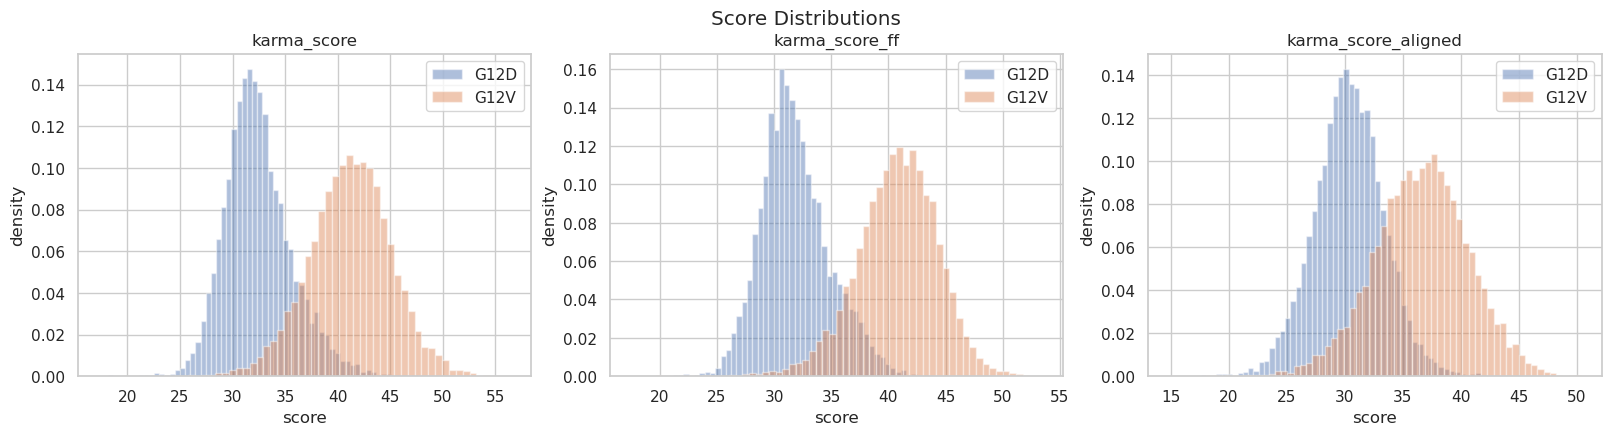

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
for ax, col in zip(axes, SCORE_COLS):
    for name, df in scores.items():
        ax.hist(df[col], bins=60, alpha=0.45, density=True, label=name)
    ax.set_title(col)
    ax.set_xlabel("score")
    ax.set_ylabel("density")
    ax.legend()
fig.suptitle("Score Distributions", y=1.05)
if SAVE_FIGURES:
    fig.savefig(OUT_DIR / "score_distributions.png", dpi=200, bbox_inches="tight")

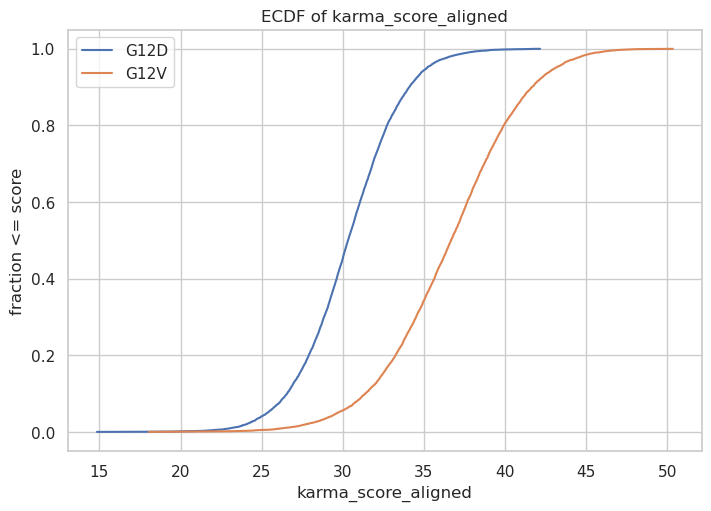

In [6]:
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
for name, df in scores.items():
    x = np.sort(df[PRIMARY_SCORE].to_numpy())
    y = np.arange(1, len(x) + 1) / len(x)
    ax.plot(x, y, label=name)
ax.set_title(f"ECDF of {PRIMARY_SCORE}")
ax.set_xlabel(PRIMARY_SCORE)
ax.set_ylabel("fraction <= score")
ax.legend()
if SAVE_FIGURES:
    fig.savefig(OUT_DIR / "aligned_score_ecdf.png", dpi=200, bbox_inches="tight")

## 单靶点内部的分数关系

这部分检查 `karma_score`、`karma_score_ff` 和 `karma_score_aligned` 之间是否一致。若某些分子 aligned 分数和 raw/ff 分数差异很大，后续可以单独检查构象或口袋对齐是否导致排序变化。


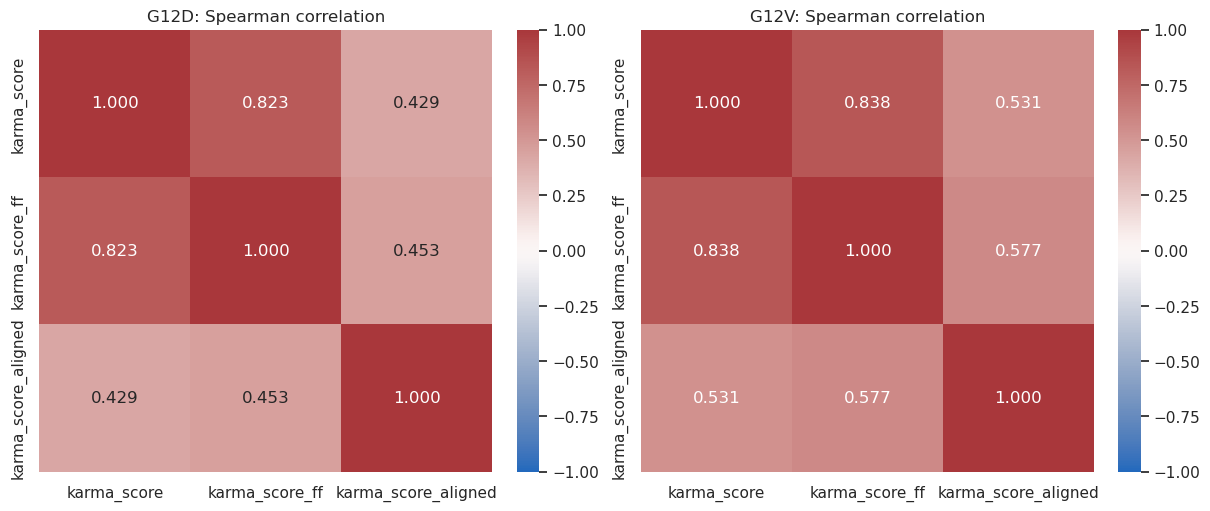

In [7]:
fig, axes = plt.subplots(1, len(scores), figsize=(6 * len(scores), 5), constrained_layout=True)
if len(scores) == 1:
    axes = [axes]
for ax, (name, df) in zip(axes, scores.items()):
    corr = df[SCORE_COLS].corr(method="spearman")
    if sns is not None:
        sns.heatmap(corr, annot=True, fmt=".3f", cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax)
    else:
        im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
        ax.set_xticks(range(len(SCORE_COLS)), SCORE_COLS, rotation=45, ha="right")
        ax.set_yticks(range(len(SCORE_COLS)), SCORE_COLS)
        for i in range(len(SCORE_COLS)):
            for j in range(len(SCORE_COLS)):
                ax.text(j, i, f"{corr.iloc[i, j]:.3f}", ha="center", va="center")
        fig.colorbar(im, ax=ax)
    ax.set_title(f"{name}: Spearman correlation")
if SAVE_FIGURES:
    fig.savefig(OUT_DIR / "score_correlation_heatmaps.png", dpi=200, bbox_inches="tight")

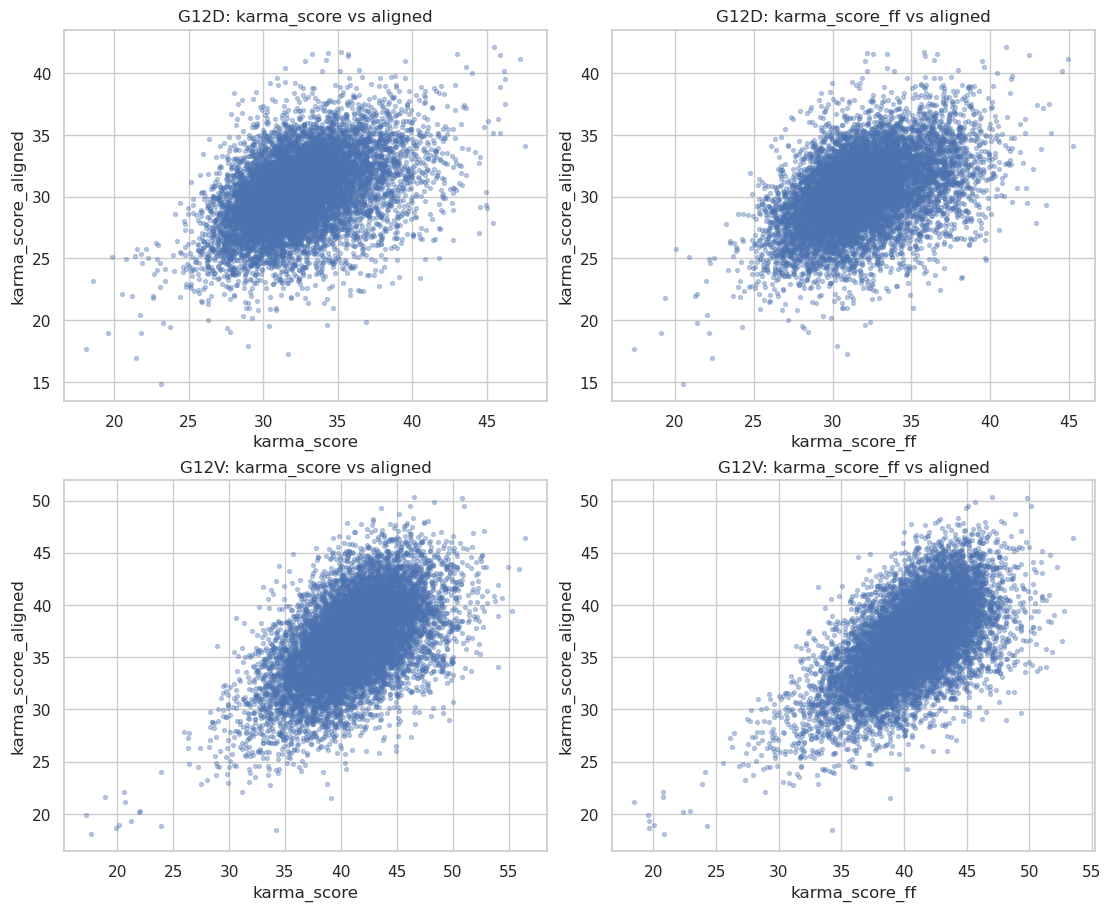

In [8]:
fig, axes = plt.subplots(len(scores), 2, figsize=(11, 4.5 * len(scores)), constrained_layout=True)
if len(scores) == 1:
    axes = np.array([axes])
for row, (name, df) in zip(axes, scores.items()):
    for ax, col in zip(row, ["karma_score", "karma_score_ff"]):
        ax.scatter(df[col], df[PRIMARY_SCORE], s=8, alpha=0.35)
        ax.set_title(f"{name}: {col} vs aligned")
        ax.set_xlabel(col)
        ax.set_ylabel(PRIMARY_SCORE)
if SAVE_FIGURES:
    fig.savefig(OUT_DIR / "raw_ff_vs_aligned_scatter.png", dpi=200, bbox_inches="tight")

## 双靶点联合筛选

下面的图和表把 G12D 与 G12V 作为一个联动筛选问题处理。

常用判断方式：
- `worst_rank` / `joint_min_pct`：保守策略，要求两个靶点都靠前。
- `rank_geomean`：rank product，允许两个靶点之间有一定不平衡。
- `pareto_front`：寻找双靶点意义下不可被同时支配的分子。


In [9]:
names = list(scores.keys())
left_name, right_name = names[0], names[1]
left = scores[left_name].drop(columns=["target"]).add_suffix(f"__{left_name}").rename(columns={f"pdb_id__{left_name}": "pdb_id"})
right = scores[right_name].drop(columns=["target"]).add_suffix(f"__{right_name}").rename(columns={f"pdb_id__{right_name}": "pdb_id"})
merged = left.merge(right, on="pdb_id", how="inner")

xcol = f"{PRIMARY_SCORE}__{left_name}"
ycol = f"{PRIMARY_SCORE}__{right_name}"
rx = f"rank_aligned__{left_name}"
ry = f"rank_aligned__{right_name}"
px = f"pct_aligned__{left_name}"
py = f"pct_aligned__{right_name}"

merged["delta_aligned"] = merged[ycol] - merged[xcol]
merged["rank_sum"] = merged[rx] + merged[ry]
merged["rank_product"] = merged[rx] * merged[ry]
merged["rank_geomean"] = np.sqrt(merged["rank_product"])
merged["best_rank"] = merged[[rx, ry]].min(axis=1)
merged["worst_rank"] = merged[[rx, ry]].max(axis=1)
merged["joint_min_pct"] = merged[[px, py]].min(axis=1)
merged["joint_mean_pct"] = merged[[px, py]].mean(axis=1)
merged["joint_balance_gap"] = (merged[px] - merged[py]).abs()
merged["joint_score"] = merged["joint_min_pct"] + 0.25 * merged["joint_mean_pct"] - 0.10 * merged["joint_balance_gap"]

# Robust within-target z scores for the primary score. Useful as a secondary aggregate view.
for name, col in [(left_name, xcol), (right_name, ycol)]:
    med = merged[col].median()
    mad = (merged[col] - med).abs().median()
    scale = 1.4826 * mad if mad > 0 else merged[col].std(ddof=0)
    merged[f"robust_z__{name}"] = (merged[col] - med) / scale
merged["joint_min_z"] = merged[[f"robust_z__{left_name}", f"robust_z__{right_name}"]].min(axis=1)
merged["joint_mean_z"] = merged[[f"robust_z__{left_name}", f"robust_z__{right_name}"]].mean(axis=1)

# Pareto front for primary scores: not dominated by any molecule with both scores >= and one score >.
front = merged.sort_values([xcol, ycol], ascending=[False, False]).copy()
front["cum_best_y_before"] = front[ycol].cummax().shift(fill_value=-np.inf)
front_ids = set(front.loc[front[ycol] > front["cum_best_y_before"], "pdb_id"])
merged["pareto_front"] = merged["pdb_id"].isin(front_ids)

print("merged rows:", merged.shape[0])
print("Pareto-front molecules:", merged["pareto_front"].sum())
display(merged[["pdb_id", xcol, ycol, rx, ry, px, py, "joint_min_pct", "worst_rank", "pareto_front"]].head())


merged rows: 9986
Pareto-front molecules: 10


,pdb_id,karma_score_aligned__G12D,karma_score_aligned__G12V,rank_aligned__G12D,rank_aligned__G12V,pct_aligned__G12D,pct_aligned__G12V,joint_min_pct,worst_rank,pareto_front
0,sample_7415,42.169510,34.996025,1,6574,1.000000,0.341844,0.341844,6574,True
1,sample_5974,41.730095,40.886368,2,1406,0.999900,0.859317,0.859317,1406,True
2,sample_4843,41.668610,40.809902,3,1443,0.999800,0.855612,0.855612,1443,False
3,sample_6184,41.599277,39.706429,4,2175,0.999700,0.782317,0.782317,2175,False
4,sample_2753,41.564251,43.662350,5,369,0.999599,0.963152,0.963152,369,True


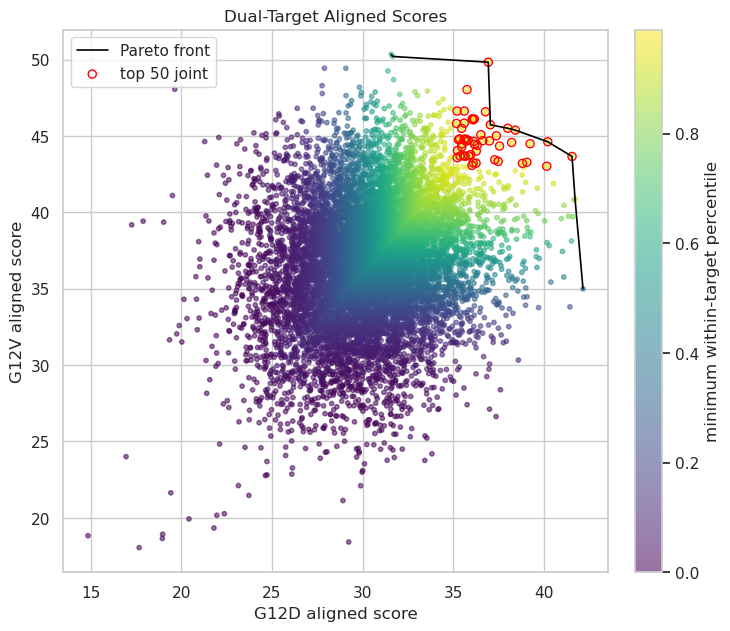

In [10]:
fig, ax = plt.subplots(figsize=(7.2, 6.2), constrained_layout=True)
sc = ax.scatter(
    merged[xcol], merged[ycol],
    c=merged["joint_min_pct"], s=10, alpha=0.55, cmap="viridis"
)
front_points = merged[merged["pareto_front"]].sort_values(xcol)
ax.plot(front_points[xcol], front_points[ycol], color="black", lw=1.2, label="Pareto front")

# Highlight the conservative dual-target top candidates.
joint_preview = merged.sort_values(["joint_min_pct", "joint_mean_pct", "worst_rank"], ascending=[False, False, True]).head(50)
ax.scatter(joint_preview[xcol], joint_preview[ycol], s=34, facecolors="none", edgecolors="red", linewidths=1.0, label="top 50 joint")

ax.set_xlabel(f"{left_name} aligned score")
ax.set_ylabel(f"{right_name} aligned score")
ax.set_title("Dual-Target Aligned Scores")
ax.legend(frameon=True)
cb = fig.colorbar(sc, ax=ax)
cb.set_label("minimum within-target percentile")
if SAVE_FIGURES:
    fig.savefig(OUT_DIR / "dual_target_aligned_scatter_pareto.png", dpi=200, bbox_inches="tight")


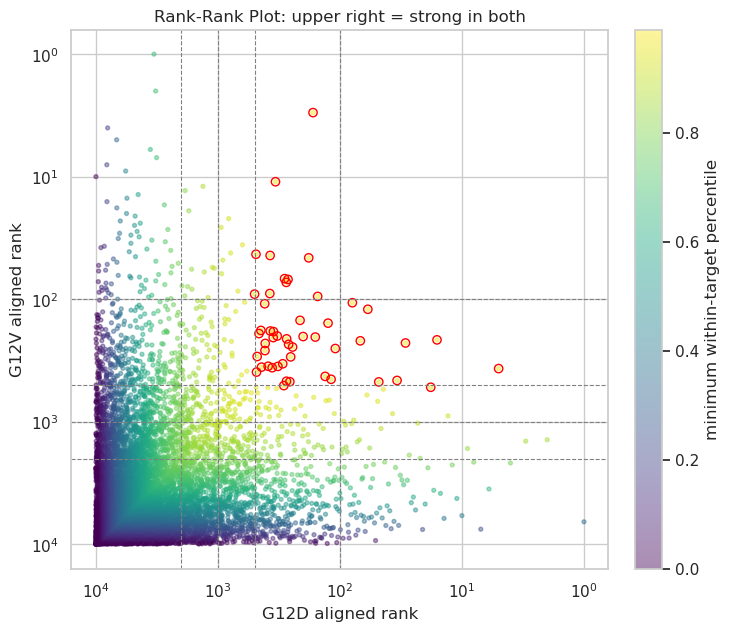

In [11]:
fig, ax = plt.subplots(figsize=(7.2, 6.2), constrained_layout=True)
sc = ax.scatter(merged[rx], merged[ry], c=merged["joint_min_pct"], s=8, alpha=0.45, cmap="viridis")
for k in [100, 500, 1000, 2000]:
    ax.axvline(k, color="gray", lw=0.8, ls="--")
    ax.axhline(k, color="gray", lw=0.8, ls="--")
ax.scatter(joint_preview[rx], joint_preview[ry], s=36, facecolors="none", edgecolors="red", linewidths=1.0)
ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_xlabel(f"{left_name} aligned rank")
ax.set_ylabel(f"{right_name} aligned rank")
ax.set_title("Rank-Rank Plot: upper right = strong in both")
cb = fig.colorbar(sc, ax=ax)
cb.set_label("minimum within-target percentile")
if SAVE_FIGURES:
    fig.savefig(OUT_DIR / "dual_target_rank_rank_plot.png", dpi=200, bbox_inches="tight")


## Top-K 重合度

这部分回答一个实际问题：如果分别取 G12D 和 G12V 的 Top K，有多少分子同时出现？

如果 Top-K 重合度很低，说明双靶点筛选不能简单取两个单靶点 Top 榜交集，需要使用 rank product、worst-rank 或分层候选池。


,k,overlap,jaccard
0,10,0,0.000000
1,20,0,0.000000
2,50,0,0.000000
3,100,0,0.000000
4,200,6,0.015228
5,500,48,0.050420
6,1000,144,0.077586
7,2000,528,0.152074


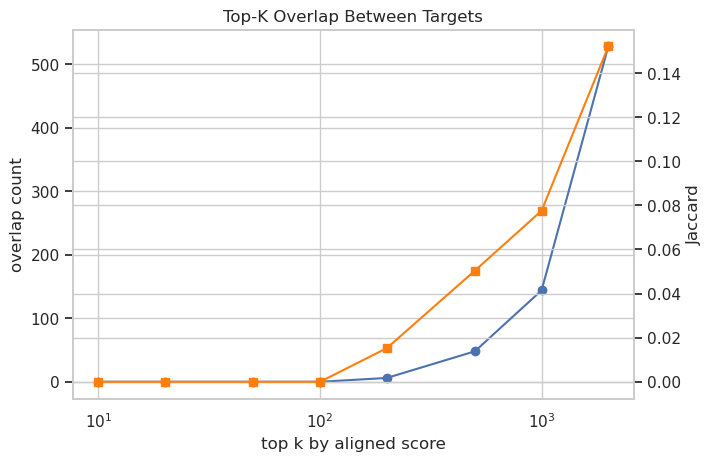

In [12]:
overlap_rows = []
for k in TOPK_VALUES:
    sets = {name: set(df.head(k)["pdb_id"]) for name, df in scores.items()}
    a, b = sets[left_name], sets[right_name]
    inter = len(a & b)
    union = len(a | b)
    overlap_rows.append({"k": k, "overlap": inter, "jaccard": inter / union if union else np.nan})
overlap = pd.DataFrame(overlap_rows)
display(overlap)

fig, ax1 = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
ax1.plot(overlap["k"], overlap["overlap"], marker="o", label="overlap count")
ax1.set_xscale("log")
ax1.set_xlabel("top k by aligned score")
ax1.set_ylabel("overlap count")
ax2 = ax1.twinx()
ax2.plot(overlap["k"], overlap["jaccard"], marker="s", color="tab:orange", label="Jaccard")
ax2.set_ylabel("Jaccard")
ax1.set_title("Top-K Overlap Between Targets")
if SAVE_FIGURES:
    fig.savefig(OUT_DIR / "topk_overlap.png", dpi=200, bbox_inches="tight")

## 放宽后的跨靶点重合检查

严格的 Top-K 交集可能非常小。这里不只问“是否同时进入两个靶点 Top100”，而是看在不同百分位阈值下有多少分子能同时保留下来。

对于 10k 规模筛选，这种百分位阈值通常比固定 Top-K 更有解释性。


,top_fraction_each_target,approx_k_each_target,both_targets_count,either_target_count,jaccard,best_worst_rank_inside
0,0.005,50,0,100,0.000000,NaN
1,0.010,100,0,200,0.000000,NaN
2,0.020,200,6,393,0.015267,107.0
3,0.050,499,47,950,0.049474,107.0
4,0.100,999,143,1854,0.077131,107.0
5,0.200,1997,527,3466,0.152048,107.0


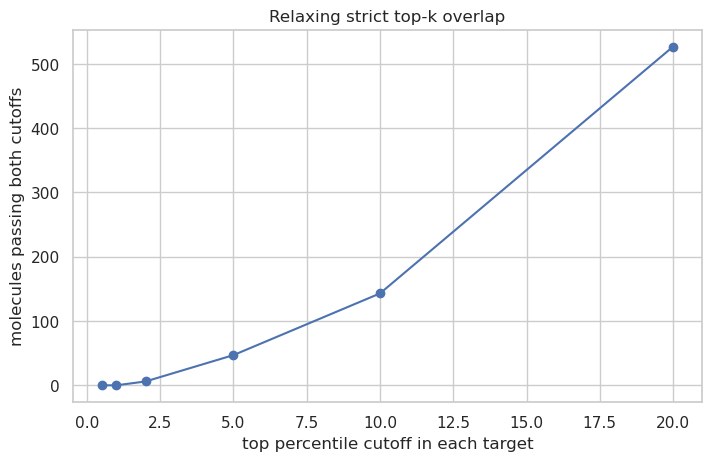

In [13]:
overlap_pct_rows = []
n_total = len(merged)
for frac in TOP_PERCENT_VALUES:
    k = max(1, int(round(n_total * frac)))
    both = (merged[rx] <= k) & (merged[ry] <= k)
    either = (merged[rx] <= k) | (merged[ry] <= k)
    overlap_pct_rows.append({
        "top_fraction_each_target": frac,
        "approx_k_each_target": k,
        "both_targets_count": int(both.sum()),
        "either_target_count": int(either.sum()),
        "jaccard": both.sum() / either.sum() if either.sum() else np.nan,
        "best_worst_rank_inside": int(merged.loc[both, "worst_rank"].min()) if both.any() else np.nan,
    })
overlap_pct = pd.DataFrame(overlap_pct_rows)
display(overlap_pct)

fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
ax.plot(overlap_pct["top_fraction_each_target"] * 100, overlap_pct["both_targets_count"], marker="o")
ax.set_xlabel("top percentile cutoff in each target")
ax.set_ylabel("molecules passing both cutoffs")
ax.set_title("Relaxing strict top-k overlap")
if SAVE_FIGURES:
    fig.savefig(OUT_DIR / "dual_target_percentile_overlap.png", dpi=200, bbox_inches="tight")


## 联合候选表

这些表更适合作为候选短名单，而不是最终结论。实际流程可以先检查前 50-200 个联合候选，再结合 pose、化学多样性、潜在结构风险，以及 CarsiDock/Glide 是否提供支持。


In [14]:
joint_cols = [
    "pdb_id", xcol, ycol, rx, ry, px, py,
    "joint_min_pct", "joint_mean_pct", "joint_balance_gap",
    "rank_sum", "rank_geomean", "worst_rank", "joint_min_z", "joint_mean_z", "pareto_front"
]

# Conservative: maximize the weaker target. This is the main dual-target table.
dual_minimax = merged.sort_values(
    ["joint_min_pct", "joint_mean_pct", "worst_rank", "rank_sum"],
    ascending=[False, False, True, True]
).head(JOINT_TOP_N)
print("Conservative dual-target candidates: maximize the weaker target")
display(dual_minimax[joint_cols])

# Rank product: useful when strict overlap is sparse; favors molecules jointly high without requiring both to be top-k.
dual_rank_product = merged.sort_values(["rank_geomean", "worst_rank", "rank_sum"]).head(JOINT_TOP_N)
print("Rank-product candidates: jointly high ranks, less strict than top-k overlap")
display(dual_rank_product[joint_cols])

# Pareto front: non-dominated candidates, then ordered by conservative joint quality.
pareto_candidates = merged[merged["pareto_front"]].sort_values(
    ["joint_min_pct", "joint_mean_pct", "worst_rank"],
    ascending=[False, False, True]
).head(JOINT_TOP_N)
print("Pareto-front candidates: no other molecule is better in both targets")
display(pareto_candidates[joint_cols])


Conservative dual-target candidates: maximize the weaker target


,pdb_id,karma_score_aligned__G12D,karma_score_aligned__G12V,rank_aligned__G12D,rank_aligned__G12V,pct_aligned__G12D,pct_aligned__G12V,joint_min_pct,joint_mean_pct,joint_balance_gap,rank_sum,rank_geomean,worst_rank,joint_min_z,joint_mean_z,pareto_front
78,sample_2546,38.014896,45.509457,79,107,0.992190,0.989386,0.989386,0.990788,0.002804,186,91.940198,107,2.206175,2.446235,True
58,sample_3775,38.436863,45.385258,59,121,0.994192,0.987984,0.987984,0.991088,0.006208,180,84.492603,121,2.175158,2.504437,True
151,sample_2896,37.056152,45.737926,152,95,0.984880,0.990588,0.984880,0.987734,0.005707,247,120.166551,152,2.263234,2.307288,True
124,sample_8766,37.383686,45.015785,125,157,0.987584,0.984380,0.984380,0.985982,0.003204,282,140.089257,157,2.082885,2.274328,False
165,sample_3416,36.939468,49.836140,166,3,0.983479,0.999800,0.983479,0.991639,0.016321,169,22.315914,166,2.310577,2.798652,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
803,sample_4735,34.462746,42.128593,804,801,0.919595,0.919896,0.919595,0.919746,0.000300,1605,802.498598,804,1.361834,1.403563,False
303,sample_4584,35.919827,42.126621,304,805,0.969661,0.919495,0.919495,0.944578,0.050165,1109,494.691823,805,1.361342,1.657845,False
804,sample_492,34.459160,42.671398,805,623,0.919495,0.937719,0.919495,0.928607,0.018224,1428,708.177238,805,1.444040,1.470717,False
810,sample_1402,34.444954,42.385994,811,710,0.918895,0.929008,0.918895,0.923951,0.010113,1521,758.821455,811,1.426118,1.432597,False


Rank-product candidates: jointly high ranks, less strict than top-k overlap


,pdb_id,karma_score_aligned__G12D,karma_score_aligned__G12V,rank_aligned__G12D,rank_aligned__G12V,pct_aligned__G12D,pct_aligned__G12V,joint_min_pct,joint_mean_pct,joint_balance_gap,rank_sum,rank_geomean,worst_rank,joint_min_z,joint_mean_z,pareto_front
165,sample_3416,36.939468,49.836140,166,3,0.983479,0.999800,0.983479,0.991639,0.016321,169,22.315914,166,2.310577,2.798652,True
4,sample_2753,41.564251,43.662350,5,369,0.999599,0.963152,0.963152,0.981376,0.036447,374,42.953463,369,1.744876,2.835599,True
1,sample_5974,41.730095,40.886368,2,1406,0.999900,0.859317,0.859317,0.929608,0.140583,1408,53.028294,1406,1.051599,2.517931,True
3336,sample_8482,31.581656,50.350502,3337,1,0.665966,1.000000,0.665966,0.832983,0.334034,3338,57.766772,3337,0.438735,1.926960,True
15,sample_5581,40.226521,44.624695,16,215,0.998498,0.978572,0.978572,0.988535,0.019926,231,58.651513,215,1.985214,2.722089,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
713,sample_2182,34.645321,45.288975,714,126,0.928607,0.987484,0.928607,0.958045,0.058877,840,299.939994,714,1.509078,1.830095,False
2695,sample_3125,32.101433,46.957912,2696,34,0.730149,0.996696,0.730149,0.863422,0.266547,2730,302.760632,2696,0.620328,1.594121,False
42,sample_2459,38.892750,39.760204,43,2138,0.995795,0.786022,0.786022,0.890908,0.209773,2181,303.206200,2138,0.770350,1.881669,False
92,sample_4810,37.794109,41.675232,93,992,0.990788,0.900771,0.900771,0.945780,0.090017,1085,303.736728,992,1.248611,1.928886,False


Pareto-front candidates: no other molecule is better in both targets


,pdb_id,karma_score_aligned__G12D,karma_score_aligned__G12V,rank_aligned__G12D,rank_aligned__G12V,pct_aligned__G12D,pct_aligned__G12V,joint_min_pct,joint_mean_pct,joint_balance_gap,rank_sum,rank_geomean,worst_rank,joint_min_z,joint_mean_z,pareto_front
78,sample_2546,38.014896,45.509457,79,107,0.992190,0.989386,0.989386,0.990788,0.002804,186,91.940198,107,2.206175,2.446235,True
58,sample_3775,38.436863,45.385258,59,121,0.994192,0.987984,0.987984,0.991088,0.006208,180,84.492603,121,2.175158,2.504437,True
151,sample_2896,37.056152,45.737926,152,95,0.984880,0.990588,0.984880,0.987734,0.005707,247,120.166551,152,2.263234,2.307288,True
165,sample_3416,36.939468,49.836140,166,3,0.983479,0.999800,0.983479,0.991639,0.016321,169,22.315914,166,2.310577,2.798652,True
15,sample_5581,40.226521,44.624695,16,215,0.998498,0.978572,0.978572,0.988535,0.019926,231,58.651513,215,1.985214,2.722089,True
4,sample_2753,41.564251,43.662350,5,369,0.999599,0.963152,0.963152,0.981376,0.036447,374,42.953463,369,1.744876,2.835599,True
1,sample_5974,41.730095,40.886368,2,1406,0.999900,0.859317,0.859317,0.929608,0.140583,1408,53.028294,1406,1.051599,2.517931,True
3230,sample_7273,31.667942,50.210110,3231,2,0.676580,0.999900,0.676580,0.838240,0.323320,3233,80.386566,3231,0.468881,1.924502,True
3336,sample_8482,31.581656,50.350502,3337,1,0.665966,1.000000,0.665966,0.832983,0.334034,3338,57.766772,3337,0.438735,1.926960,True
0,sample_7415,42.169510,34.996025,1,6574,1.000000,0.341844,0.341844,0.670922,0.658156,6575,81.080207,6574,-0.419463,1.859158,True


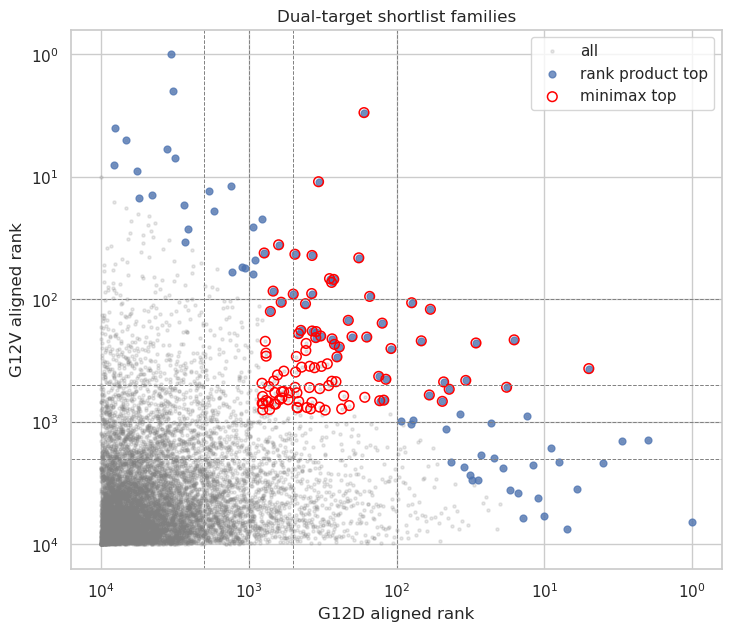

In [15]:
# Visualize where the shortlist families sit in rank space.
fig, ax = plt.subplots(figsize=(7.2, 6.2), constrained_layout=True)
ax.scatter(merged[rx], merged[ry], s=5, alpha=0.18, color="gray", label="all")
ax.scatter(dual_rank_product[rx], dual_rank_product[ry], s=24, alpha=0.75, label="rank product top")
ax.scatter(dual_minimax[rx], dual_minimax[ry], s=48, facecolors="none", edgecolors="red", linewidths=1.1, label="minimax top")
for k in [100, 500, 1000, 2000]:
    ax.axvline(k, color="gray", lw=0.7, ls="--")
    ax.axhline(k, color="gray", lw=0.7, ls="--")
ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_xlabel(f"{left_name} aligned rank")
ax.set_ylabel(f"{right_name} aligned rank")
ax.set_title("Dual-target shortlist families")
ax.legend(frameon=True)
if SAVE_FIGURES:
    fig.savefig(OUT_DIR / "dual_target_shortlist_families.png", dpi=200, bbox_inches="tight")


## 单靶点偏向性检查

这一部分是辅助检查。主候选应来自前面的联合排序；偏向性列表用于识别可能只对某一个突变体表现较好的分子。


In [16]:
print(f"Top {TOP_N} by {PRIMARY_SCORE}")
for name, df in scores.items():
    print("\n", name)
    display(df.head(TOP_N))

Top 100 by karma_score_aligned

 G12D


,pdb_id,karma_score,karma_score_ff,karma_score_aligned,target,rank_karma_score,pct_karma_score,rank_karma_score_ff,pct_karma_score_ff,rank_karma_score_aligned,pct_karma_score_aligned,rank_aligned,pct_aligned
0,sample_7415,45.453091,41.018364,42.169510,G12D,10,0.999099,36,0.996495,1,1.000000,1,1.000000
1,sample_5974,35.196850,35.806988,41.730095,G12D,1766,0.823270,1105,0.889456,2,0.999900,2,0.999900
2,sample_4843,34.315937,32.160412,41.668610,G12D,2430,0.756784,4111,0.588465,3,0.999800,3,0.999800
3,sample_6184,35.682884,32.596535,41.599277,G12D,1454,0.854511,3558,0.643837,4,0.999700,4,0.999700
4,sample_2753,33.269436,33.483528,41.564251,G12D,3421,0.657555,2623,0.737459,5,0.999599,5,0.999599
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,sample_4043,39.105877,37.595631,37.746254,G12D,325,0.967558,428,0.957244,96,0.990488,96,0.990488
96,sample_9228,30.786808,31.022738,37.740818,G12D,6898,0.309402,5749,0.424452,97,0.990388,97,0.990388
97,sample_4664,34.555809,32.567463,37.721615,G12D,2251,0.774707,3598,0.639832,98,0.990287,98,0.990287
98,sample_3640,34.313046,33.121490,37.702484,G12D,2431,0.756684,2964,0.703314,99,0.990187,99,0.990187



 G12V


,pdb_id,karma_score,karma_score_ff,karma_score_aligned,target,rank_karma_score,pct_karma_score,rank_karma_score_ff,pct_karma_score_ff,rank_karma_score_aligned,pct_karma_score_aligned,rank_aligned,pct_aligned
0,sample_8482,46.537834,47.055069,50.350502,G12V,767,0.923300,265,0.973566,1,1.000000,1,1.000000
1,sample_7273,50.811787,49.830418,50.210110,G12V,71,0.992991,44,0.995694,2,0.999900,2,0.999900
2,sample_3416,48.286167,45.701359,49.836140,G12V,314,0.968659,651,0.934915,3,0.999800,3,0.999800
3,sample_2994,50.961655,50.119884,49.440201,G12V,62,0.993892,38,0.996295,4,0.999700,4,0.999700
4,sample_3916,46.171143,45.085411,49.435192,G12V,927,0.907279,926,0.907380,5,0.999599,5,0.999599
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,sample_4213,49.203472,45.213184,45.734325,G12V,200,0.980074,860,0.913988,96,0.990488,96,0.990488
96,sample_8829,47.018314,43.503563,45.733288,G12V,613,0.938720,2135,0.786322,97,0.990388,97,0.990388
97,sample_1908,44.026134,42.796970,45.728981,G12V,2231,0.776710,2826,0.717132,98,0.990287,98,0.990287
98,sample_303,46.001080,44.141766,45.689827,G12V,995,0.900471,1563,0.843597,99,0.990187,99,0.990187


In [17]:
# Compatibility table for the older "common hits" idea.
# This is equivalent to a minimax-rank shortlist and is less informative than the percentile tables above.
common = merged.sort_values(["worst_rank", "rank_sum"]).head(TOP_N)
display(common[[
    "pdb_id", xcol, ycol, "delta_aligned",
    rx, ry, "rank_sum", "rank_geomean", "worst_rank", "joint_min_pct", "pareto_front"
]])


,pdb_id,karma_score_aligned__G12D,karma_score_aligned__G12V,delta_aligned,rank_aligned__G12D,rank_aligned__G12V,rank_sum,rank_geomean,worst_rank,joint_min_pct,pareto_front
78,sample_2546,38.014896,45.509457,7.494560,79,107,186,91.940198,107,0.989386,True
58,sample_3775,38.436863,45.385258,6.948395,59,121,180,84.492603,121,0.987984,True
151,sample_2896,37.056152,45.737926,8.681774,152,95,247,120.166551,152,0.984880,True
124,sample_8766,37.383686,45.015785,7.632099,125,157,282,140.089257,157,0.984380,False
165,sample_3416,36.939468,49.836140,12.896671,166,3,169,22.315914,166,0.983479,True
...,...,...,...,...,...,...,...,...,...,...,...
803,sample_4735,34.462746,42.128593,7.665848,804,801,1605,802.498598,804,0.919595,False
303,sample_4584,35.919827,42.126621,6.206795,304,805,1109,494.691823,805,0.919495,False
804,sample_492,34.459160,42.671398,8.212238,805,623,1428,708.177238,805,0.919495,False
810,sample_1402,34.444954,42.385994,7.941040,811,710,1521,758.821455,811,0.918895,False


In [18]:
# Target-biased candidates: high in one target and relatively weaker in the other.
# Useful for filtering out molecules that are not truly dual-target.
right_selective = merged.sort_values([ry, "delta_aligned"], ascending=[True, False]).head(500)
right_selective = right_selective.sort_values("delta_aligned", ascending=False).head(TOP_N)

left_selective = merged.sort_values([rx, "delta_aligned"], ascending=[True, True]).head(500)
left_selective = left_selective.sort_values("delta_aligned", ascending=True).head(TOP_N)

print(f"{right_name}-biased candidates")
display(right_selective[["pdb_id", xcol, ycol, "delta_aligned", rx, ry, px, py, "joint_min_pct"]])

print(f"{left_name}-biased candidates")
display(left_selective[["pdb_id", xcol, ycol, "delta_aligned", rx, ry, px, py, "joint_min_pct"]])


G12V-biased candidates


,pdb_id,karma_score_aligned__G12D,karma_score_aligned__G12V,delta_aligned,rank_aligned__G12D,rank_aligned__G12V,pct_aligned__G12D,pct_aligned__G12V,joint_min_pct
9974,sample_5085,19.632523,48.063610,28.431087,9977,10,0.001101,0.999099,0.001101
9960,sample_3566,21.285967,44.642063,23.356096,9963,212,0.002503,0.978873,0.002503
9936,sample_1857,22.064457,44.905678,22.841221,9939,169,0.004906,0.983178,0.004906
7998,sample_2994,27.896296,49.440201,21.543905,7999,4,0.199159,0.999700,0.199159
9871,sample_4337,23.264935,44.761288,21.496353,9874,189,0.011415,0.981176,0.011415
...,...,...,...,...,...,...,...,...,...
8782,sample_3648,26.882116,43.624737,16.742620,8785,384,0.120457,0.961650,0.120457
7325,sample_3187,28.565838,45.247250,16.681412,7326,129,0.266547,0.987183,0.266547
5320,sample_674,30.093100,46.762459,16.669359,5321,41,0.467307,0.995995,0.467307
8689,sample_5803,26.998457,43.652729,16.654272,8691,373,0.129869,0.962752,0.129869


G12D-biased candidates


,pdb_id,karma_score_aligned__G12D,karma_score_aligned__G12V,delta_aligned,rank_aligned__G12D,rank_aligned__G12V,pct_aligned__G12D,pct_aligned__G12V,joint_min_pct
126,sample_5093,37.372154,26.629877,-10.742277,127,9878,0.987384,0.011014,0.011014
157,sample_4241,37.010792,27.119333,-9.891459,158,9846,0.984280,0.014218,0.014218
105,sample_9049,37.612740,28.388214,-9.224525,106,9721,0.989486,0.026735,0.026735
334,sample_3522,35.771610,27.408775,-8.362835,335,9822,0.966557,0.016622,0.016622
50,sample_3208,38.598969,30.330061,-8.268908,51,9349,0.994993,0.063983,0.063983
...,...,...,...,...,...,...,...,...,...
264,sample_8993,36.171097,33.883522,-2.287575,265,7512,0.973566,0.247922,0.247922
318,sample_4562,35.857502,33.625420,-2.232082,319,7730,0.968159,0.226094,0.226094
46,sample_3834,38.836201,36.613529,-2.222672,47,5057,0.995394,0.493742,0.493742
366,sample_3296,35.638905,33.433289,-2.205616,367,7858,0.963352,0.213277,0.213277


## Correction Shift

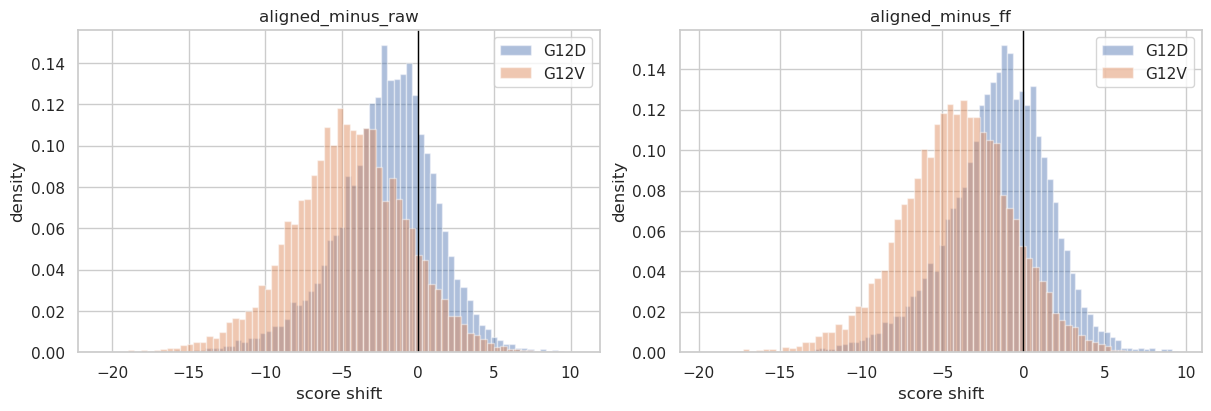

In [19]:
shift_frames = []
for name, df in scores.items():
    tmp = df[["pdb_id", "karma_score", "karma_score_ff", "karma_score_aligned"]].copy()
    tmp["target"] = name
    tmp["aligned_minus_raw"] = tmp["karma_score_aligned"] - tmp["karma_score"]
    tmp["aligned_minus_ff"] = tmp["karma_score_aligned"] - tmp["karma_score_ff"]
    shift_frames.append(tmp)
shift = pd.concat(shift_frames, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, col in zip(axes, ["aligned_minus_raw", "aligned_minus_ff"]):
    for name in scores:
        vals = shift.loc[shift["target"] == name, col]
        ax.hist(vals, bins=70, alpha=0.45, density=True, label=name)
    ax.axvline(0, color="black", lw=1)
    ax.set_title(col)
    ax.set_xlabel("score shift")
    ax.set_ylabel("density")
    ax.legend()
if SAVE_FIGURES:
    fig.savefig(OUT_DIR / "correction_shift_distributions.png", dpi=200, bbox_inches="tight")

In [20]:
print("Largest positive aligned-minus-raw shifts")
display(shift.sort_values("aligned_minus_raw", ascending=False).head(30))

print("Largest negative aligned-minus-raw shifts")
display(shift.sort_values("aligned_minus_raw", ascending=True).head(30))

Largest positive aligned-minus-raw shifts


,pdb_id,karma_score,karma_score_ff,karma_score_aligned,target,aligned_minus_raw,aligned_minus_ff
60,sample_8176,28.021034,29.266531,38.386597,G12D,10.365562,9.120066
86,sample_3807,28.552826,29.121286,37.865032,G12D,9.312206,8.743746
111,sample_3083,28.283167,29.744139,37.538368,G12D,9.255201,7.794230
10341,sample_2791,34.469406,40.721542,43.703091,G12V,9.233685,2.981548
10162,sample_9285,35.739681,37.245411,44.867512,G12V,9.127831,7.622101
56,sample_9366,29.472507,29.817547,38.463005,G12D,8.990498,8.645458
13,sample_6221,31.464170,33.460361,40.395512,G12D,8.931341,6.935150
187,sample_9609,27.835526,30.200565,36.725498,G12D,8.889973,6.524933
29,sample_9263,30.456532,31.753424,39.244747,G12D,8.788216,7.491323
22,sample_2486,30.910196,31.883924,39.649189,G12D,8.738993,7.765265


Largest negative aligned-minus-raw shifts


,pdb_id,karma_score,karma_score_ff,karma_score_aligned,target,aligned_minus_raw,aligned_minus_ff
19625,sample_6308,49.672646,48.120811,28.960440,G12V,-20.712206,-19.160372
17330,sample_8908,54.041908,51.341217,34.094753,G12V,-19.947155,-17.246464
19486,sample_8485,49.085220,49.344528,29.643930,G12V,-19.441290,-19.700598
19225,sample_891,50.016224,47.564838,30.711193,G12V,-19.305031,-16.853645
19814,sample_9553,46.280151,43.730988,27.361403,G12V,-18.918749,-16.369585
19895,sample_9125,44.913628,43.416866,26.020519,G12V,-18.893108,-17.396347
19358,sample_1415,49.111126,45.993099,30.248960,G12V,-18.862165,-15.744139
19555,sample_3824,48.068245,45.199116,29.341579,G12V,-18.726665,-15.857536
19870,sample_1638,44.896709,41.435455,26.476252,G12V,-18.420458,-14.959204
19398,sample_3818,48.217941,44.920723,30.092262,G12V,-18.125679,-14.828461


## Optional Exports

In [21]:
if EXPORT_TABLES:
    for name, df in scores.items():
        df.to_csv(OUT_DIR / f"{name}_sorted_by_aligned.csv", index=False)
    merged.to_csv(OUT_DIR / "merged_scores.csv", index=False)
    common.to_csv(OUT_DIR / "common_strong_hits.csv", index=False)
    dual_minimax.to_csv(OUT_DIR / "dual_target_minimax_candidates.csv", index=False)
    dual_rank_product.to_csv(OUT_DIR / "dual_target_rank_product_candidates.csv", index=False)
    pareto_candidates.to_csv(OUT_DIR / "dual_target_pareto_candidates.csv", index=False)
    right_selective.to_csv(OUT_DIR / f"{right_name}_biased_hits.csv", index=False)
    left_selective.to_csv(OUT_DIR / f"{left_name}_biased_hits.csv", index=False)
    overlap.to_csv(OUT_DIR / "topk_overlap.csv", index=False)
    overlap_pct.to_csv(OUT_DIR / "dual_target_percentile_overlap.csv", index=False)
    print(f"Exported tables to {OUT_DIR}")
else:
    print("EXPORT_TABLES is False; no CSV files written.")


EXPORT_TABLES is False; no CSV files written.



## CarsiDock 双靶点分析

CarsiDock 对每个对接后的分子给出一个分数。这里先把 CarsiDock 输出中的 InChIKey 形式 ID 映射回原始 `sample_10k` 的 `sample_id`，再把 G12D 与 G12V 放在一起做联动分析。下方默认把 CarsiDock 分数理解为越高越好。

需要注意：输入库中有少量重复结构，多个 `sample_id` 会对应同一个 InChIKey。因此 notebook 同时保留结构层面的结果和样本层面的结果，避免把重复结构误认为独立分子。


In [22]:

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

try:
    from rdkit import Chem
except Exception as exc:
    Chem = None
    print(f"RDKit is required for CarsiDock ID mapping: {exc}")

EXPORT_TABLES = False
EXPORT_DIR = Path("/home/aidd/CarsiDock/analysis_exports")

CARSIDOCK_PATHS = {
    "G12D": Path("/mnt/data/CarsiDock/outputs/g12d_sample10k/sample10k_smiles_score.dat"),
    "G12V": Path("/mnt/data/CarsiDock/outputs/g12v_sample10k/sample10k_smiles_score.dat"),
}
KARMADOCK_PATHS = {
    "G12D": Path("/mnt/data/KarmaDock/screening_runs/runs/7rpz_sample10k/full_result/score.csv"),
    "G12V": Path("/mnt/data/KarmaDock/screening_runs/runs/g12v_sample10k_br7/full_result/score.csv"),
}
SAMPLE_MAP_PATH = Path("/mnt/data/CarsiDock/inputs/karmadock_sample10k/sample10k_id_map.csv")
INCHIKEY_RE = re.compile(r"^([A-Z]{14}-[A-Z]{10}-[A-Z])")


In [23]:

def smiles_to_inchikey(smiles):
    if Chem is None or pd.isna(smiles):
        return np.nan
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.nan
    return Chem.MolToInchiKey(mol)

sample_map = pd.read_csv(SAMPLE_MAP_PATH)
sample_map["inchikey"] = sample_map["smiles"].map(smiles_to_inchikey)

# Structure-level mapping keeps duplicate sample IDs visible instead of silently dropping them.
structure_map = (
    sample_map.dropna(subset=["inchikey"])
    .groupby("inchikey", as_index=False)
    .agg(
        sample_id_primary=("sample_id", "first"),
        sample_ids=("sample_id", lambda s: ";".join(s)),
        n_sample_ids=("sample_id", "size"),
        smiles=("smiles", "first"),
    )
)

duplicate_structures = structure_map.query("n_sample_ids > 1").copy()
print(f"sample rows: {len(sample_map):,}")
print(f"unique InChIKeys: {structure_map['inchikey'].nunique():,}")
print(f"duplicate InChIKey groups: {len(duplicate_structures):,}")
duplicate_structures.head(10)


sample rows: 10,000
unique InChIKeys: 9,994
duplicate InChIKey groups: 6


,inchikey,sample_id_primary,sample_ids,n_sample_ids,smiles
3974,KUYWUEWXBHFYRE-UHFFFAOYSA-N,sample_3424,sample_3424;sample_9446,2,Cc1nc2c(F)c(-c3cccc(Cl)c3Cl)c(CCC#N)cc2c2c1cc(...
4244,LMFPYESUPRKJAX-UHFFFAOYSA-N,sample_1186,sample_1186;sample_5480,2,C#Cc1c(F)ccc2cc(O)cc(-c3nc4c(N5CC6CCC(C5)N6)nc...
4619,MLKRCYGZHPWOAF-UHFFFAOYSA-N,sample_6542,sample_6542;sample_7078,2,Cc1nc2c(F)c(-c3cccc(Cl)c3Cl)c(CCC#N)cc2c2c1cc(...
5359,OEOPMMNFSUASOU-UHFFFAOYSA-N,sample_602,sample_602;sample_5552,2,CCc1cccc2cccc(N3CCc4c(nc(OCC56CCCN5CCC6)nc4N4C...
7732,UOTBNHXWYQAYAK-UHFFFAOYSA-N,sample_796,sample_796;sample_3992,2,CCc1cccc2cc(O)cc(-c3nc4c(N5CC6CCC(C5)N6)nc(OCC...
9811,ZOODRZHEXZHYDS-UHFFFAOYSA-N,sample_1436,sample_1436;sample_9280,2,CCc1cccc2cccc(N3CCc4c(nc(OCC56CCCN5CCC6)nc4NCc...


In [24]:

def load_carsidock_scores(target, path):
    raw = pd.read_csv(path, sep="\t")
    raw = raw.rename(columns={"#code_ligand_num": "carsidock_id", "score": f"carsidock_{target.lower()}"})
    raw["inchikey"] = raw["carsidock_id"].astype(str).str.extract(INCHIKEY_RE)
    raw["target"] = target
    score_col = f"carsidock_{target.lower()}"

    # Multiple rows for the same InChIKey can occur when duplicate structures exist in the input.
    # Keep the best score for ranking, and keep counts for diagnostics.
    struct = (
        raw.dropna(subset=["inchikey"])
        .groupby("inchikey", as_index=False)
        .agg(
            **{score_col: (score_col, "max")},
            n_carsidock_rows=("carsidock_id", "size"),
            carsidock_ids=("carsidock_id", lambda s: ";".join(s.astype(str).head(5))),
        )
        .merge(structure_map, on="inchikey", how="left")
    )
    struct[f"{score_col}_rank"] = struct[score_col].rank(ascending=False, method="min")
    struct[f"{score_col}_pct"] = struct[score_col].rank(ascending=False, pct=True, method="min")
    return raw, struct

cars_raw = {}
cars_struct = []
for target, path in CARSIDOCK_PATHS.items():
    raw, struct = load_carsidock_scores(target, path)
    cars_raw[target] = raw
    cars_struct.append(struct)
    print(f"{target}: raw rows={len(raw):,}, unique scored InChIKeys={struct['inchikey'].nunique():,}, mapped structures={struct['sample_id_primary'].notna().sum():,}")

cars_wide = cars_struct[0]
for df in cars_struct[1:]:
    keep = ["inchikey"] + [c for c in df.columns if c.startswith("carsidock_")]
    cars_wide = cars_wide.merge(df[keep], on="inchikey", how="outer")

cars_wide = cars_wide.merge(structure_map, on="inchikey", how="left", suffixes=("", "_map"))
for c in ["sample_id_primary_map", "sample_ids_map", "n_sample_ids_map", "smiles_map"]:
    if c in cars_wide.columns:
        base = c.replace("_map", "")
        cars_wide[base] = cars_wide[base].combine_first(cars_wide[c])
        cars_wide = cars_wide.drop(columns=[c])

print("common scored structures:", cars_wide.dropna(subset=["carsidock_g12d", "carsidock_g12v"]).shape[0])
cars_wide.head()


G12D: raw rows=9,998, unique scored InChIKeys=9,991, mapped structures=9,991
G12V: raw rows=9,997, unique scored InChIKeys=9,990, mapped structures=9,990
common scored structures: 9990


,inchikey,carsidock_g12d,n_carsidock_rows,carsidock_ids_x,sample_id_primary,sample_ids,n_sample_ids,smiles,carsidock_g12d_rank,carsidock_g12d_pct,carsidock_g12v,carsidock_ids_y,carsidock_g12v_rank,carsidock_g12v_pct
0,AAABWLYUEVRUQV-UHFFFAOYSA-N,52.122169,1,AAABWLYUEVRUQV-UHFFFAOYSA-N-869,sample_1871,sample_1871,1,CCNC(=O)c1cc2n(n1)CCCN(c1nc(OCC34CCCN3CC(F)C4)...,7704.0,0.771094,56.461609,AAABWLYUEVRUQV-UHFFFAOYSA-N-869,8982.0,0.899099
1,AAGIBHCVBCHPMZ-UHFFFAOYSA-N,56.299890,1,AAGIBHCVBCHPMZ-UHFFFAOYSA-N-530,sample_1532,sample_1532,1,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CCCC(O)CC5)nc(...,5073.0,0.507757,63.006118,AAGIBHCVBCHPMZ-UHFFFAOYSA-N-530,5609.0,0.561461
2,AAMVGSZMEHIANF-UHFFFAOYSA-N,48.172330,1,AAMVGSZMEHIANF-UHFFFAOYSA-N-107,sample_6110,sample_6110,1,CC1CCCc2cc(OS(=O)(=O)c3ccc(C(F)(F)F)cc3)cc(-c3...,8957.0,0.896507,59.467666,AAMVGSZMEHIANF-UHFFFAOYSA-N-107,7858.0,0.786587
3,AANUNHIWAOSTSL-UHFFFAOYSA-N,55.778190,1,AANUNHIWAOSTSL-UHFFFAOYSA-N-6,sample_7009,sample_7009,1,C#Cc1c(F)ccc2cc(O)cc(-c3nc4c5c(nc(OCC6(CN7CCOC...,5465.0,0.546992,66.630352,AANUNHIWAOSTSL-UHFFFAOYSA-N-6,2993.0,0.299600
4,AAOXDSJEJXQQHG-UHFFFAOYSA-N,51.087199,1,AAOXDSJEJXQQHG-UHFFFAOYSA-N-99,sample_101,sample_101,1,CCc1cccc2cc(O)cc(-c3ncc4c(N5CC6CC(O)C(C6)C5)nc...,8132.0,0.813933,58.623137,AAOXDSJEJXQQHG-UHFFFAOYSA-N-99,8240.0,0.824825



### CarsiDock 的 G12D/G12V 联合排序

我们的目标不是找某一个靶点上最高的分子，而是找在两个靶点上都稳定靠前的分子。这里主要使用几个保守指标：

- `carsidock_joint_min_score`：两个靶点中较弱的那个分数，越高越好。
- `carsidock_worst_pct`：两个靶点中较差的百分位排名，越低越好。
- `carsidock_rank_product`：两个靶点排名的几何平均，越低越好。


In [25]:

cars_joint = cars_wide.dropna(subset=["carsidock_g12d", "carsidock_g12v"]).copy()
cars_joint["carsidock_joint_min_score"] = cars_joint[["carsidock_g12d", "carsidock_g12v"]].min(axis=1)
cars_joint["carsidock_joint_mean_score"] = cars_joint[["carsidock_g12d", "carsidock_g12v"]].mean(axis=1)
cars_joint["carsidock_worst_pct"] = cars_joint[["carsidock_g12d_pct", "carsidock_g12v_pct"]].max(axis=1)
cars_joint["carsidock_rank_product"] = np.sqrt(cars_joint["carsidock_g12d_rank"] * cars_joint["carsidock_g12v_rank"])

cars_joint_top = cars_joint.sort_values(["carsidock_worst_pct", "carsidock_rank_product", "carsidock_joint_min_score"], ascending=[True, True, False])
show_cols = [
    "sample_id_primary", "sample_ids", "n_sample_ids", "inchikey",
    "carsidock_g12d", "carsidock_g12v", "carsidock_g12d_pct", "carsidock_g12v_pct",
    "carsidock_worst_pct", "carsidock_rank_product", "carsidock_joint_min_score",
]
if EXPORT_TABLES:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    cars_joint_top[show_cols + ["smiles"]].to_csv(EXPORT_DIR / "carsidock_dual_target_ranked.csv", index=False)

cars_joint_top[show_cols].head(30)


,sample_id_primary,sample_ids,n_sample_ids,inchikey,carsidock_g12d,carsidock_g12v,carsidock_g12d_pct,carsidock_g12v_pct,carsidock_worst_pct,carsidock_rank_product,carsidock_joint_min_score
4089,sample_3114,sample_3114,1,LCOWBYASVSRGKJ-UHFFFAOYSA-N,68.273238,79.735618,0.004904,0.002903,0.004904,37.696154,68.273238
5606,sample_377,sample_377,1,OTHCGBDVYGKPHJ-UHFFFAOYSA-N,68.873557,78.500804,0.003103,0.005205,0.005205,40.149720,68.873557
9356,sample_2963,sample_2963,1,YMTMWIHZUVHTAZ-UHFFFAOYSA-N,67.724874,78.132102,0.006906,0.006607,0.006906,67.483331,67.724874
3613,sample_7861,sample_7861,1,JVRHTFAWROKXTR-UHFFFAOYSA-N,70.031323,78.006595,0.000901,0.007007,0.007007,25.099801,70.031323
8534,sample_1126,sample_1126,1,WNOOWQJPVIELCO-UHFFFAOYSA-N,69.654189,77.818049,0.001301,0.007407,0.007407,31.016125,69.654189
8853,sample_8741,sample_8741,1,XGSQDRLYKKCRML-UHFFFAOYSA-N,68.771316,77.793509,0.003203,0.007508,0.007508,48.989795,68.771316
7244,sample_252,sample_252,1,SSPLTBLNFNATFY-UHFFFAOYSA-N,69.544510,77.652440,0.001601,0.008108,0.008108,36.000000,69.544510
7580,sample_1728,sample_1728,1,UGNAARDUCKCHGV-UHFFFAOYSA-N,68.049417,77.363568,0.005605,0.008709,0.008709,69.799713,68.049417
7893,sample_9925,sample_9925,1,UYAPJYWYTAYCRL-UHFFFAOYSA-N,70.564629,77.205958,0.000400,0.009109,0.009109,19.078784,70.564629
8979,sample_596,sample_596,1,XOMGBKZULFXMKK-UHFFFAOYSA-N,68.066505,77.062264,0.005305,0.009710,0.009710,71.700767,68.066505


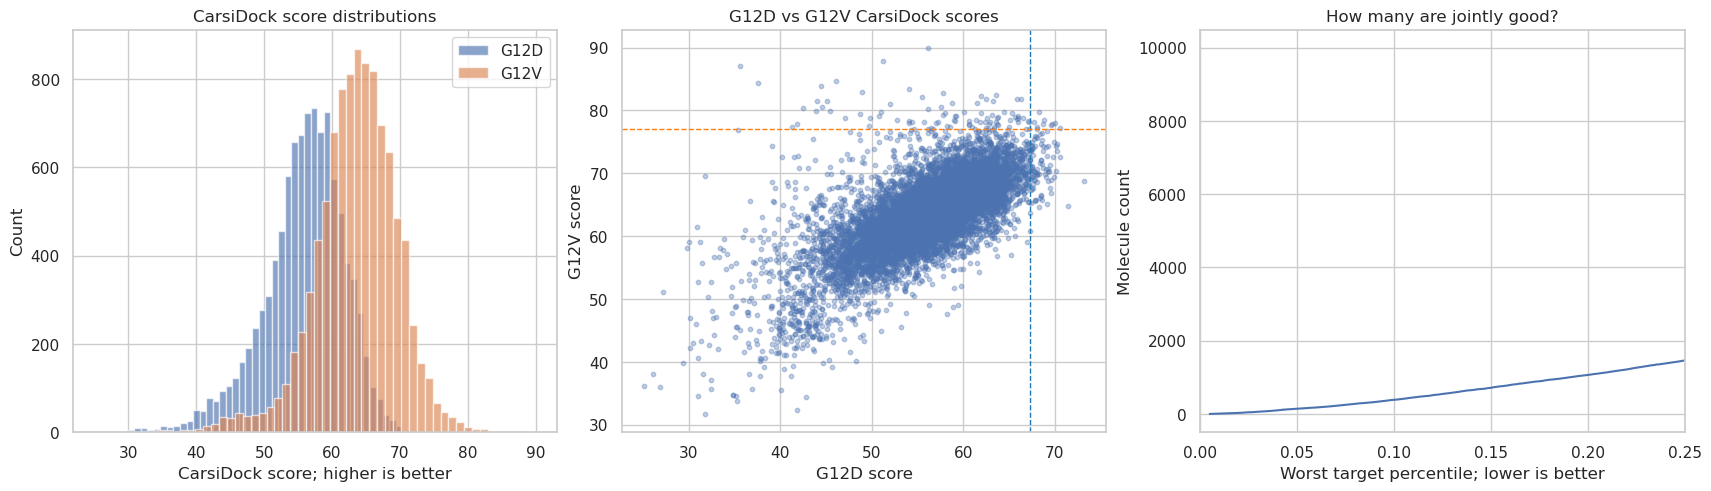

In [26]:

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), constrained_layout=True)

axes[0].hist(cars_wide["carsidock_g12d"].dropna(), bins=50, alpha=0.65, label="G12D")
axes[0].hist(cars_wide["carsidock_g12v"].dropna(), bins=50, alpha=0.65, label="G12V")
axes[0].set_title("CarsiDock score distributions")
axes[0].set_xlabel("CarsiDock score; higher is better")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].scatter(cars_joint["carsidock_g12d"], cars_joint["carsidock_g12v"], s=10, alpha=0.35)
q_d = cars_joint["carsidock_g12d"].quantile(0.99)
q_v = cars_joint["carsidock_g12v"].quantile(0.99)
axes[1].axvline(q_d, ls="--", color="tab:blue", lw=1)
axes[1].axhline(q_v, ls="--", color="tab:orange", lw=1)
axes[1].set_title("G12D vs G12V CarsiDock scores")
axes[1].set_xlabel("G12D score")
axes[1].set_ylabel("G12V score")

x = np.sort(cars_joint["carsidock_worst_pct"].to_numpy())
y = np.arange(1, len(x) + 1)
axes[2].plot(x, y)
axes[2].set_title("How many are jointly good?")
axes[2].set_xlabel("Worst target percentile; lower is better")
axes[2].set_ylabel("Molecule count")
axes[2].set_xlim(0, min(0.25, np.nanmax(x)))

plt.show()


In [27]:

thresholds = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10]
overlap_rows = []
for t in thresholds:
    top_d = set(cars_wide.loc[cars_wide["carsidock_g12d_pct"] <= t, "inchikey"])
    top_v = set(cars_wide.loc[cars_wide["carsidock_g12v_pct"] <= t, "inchikey"])
    both = top_d & top_v
    union = top_d | top_v
    relaxed = set(cars_joint.loc[cars_joint["carsidock_worst_pct"] <= t, "inchikey"])
    overlap_rows.append({
        "top_fraction_each_target": t,
        "top_g12d": len(top_d),
        "top_g12v": len(top_v),
        "strict_overlap": len(both),
        "jaccard": len(both) / len(union) if union else np.nan,
        "worst_pct_joint_count": len(relaxed),
    })
overlap = pd.DataFrame(overlap_rows)
overlap


,top_fraction_each_target,top_g12d,top_g12v,strict_overlap,jaccard,worst_pct_joint_count
0,0.001,9,9,0,0.000000,0
1,0.005,49,49,1,0.010309,1
2,0.010,99,99,10,0.053191,10
3,0.020,199,199,28,0.075676,28
4,0.050,499,499,140,0.163170,140
5,0.100,999,999,387,0.240223,387



### CarsiDock 与 KarmaDock 的联合比较

KarmaDock 有三个分数；这里沿用前面 notebook 的主指标 `karma_score_aligned`。CarsiDock 通过 InChIKey 映射回 `sample_id` 后，就可以和 KarmaDock 在同一批分子上比较。

这部分重点看两件事：

- 两个方法在同一靶点、同一批分子上的相关性是否高。
- 是否存在同时被 KarmaDock 和 CarsiDock 支持的双靶点候选。


In [28]:

def load_karma_scores(target, path):
    df = pd.read_csv(path)
    df = df.rename(columns={
        "pdb_id": "sample_id",
        "karma_score": f"karma_{target.lower()}",
        "karma_score_ff": f"karma_ff_{target.lower()}",
        "karma_score_aligned": f"karma_aligned_{target.lower()}",
    })
    return df

karma = None
for target, path in KARMADOCK_PATHS.items():
    df = load_karma_scores(target, path)
    karma = df if karma is None else karma.merge(df, on="sample_id", how="outer")

# Expand CarsiDock structure-level scores back to sample IDs, preserving duplicated structures.
carsi_sample = sample_map[["sample_id", "inchikey", "smiles"]].merge(
    cars_joint[[
        "inchikey", "carsidock_g12d", "carsidock_g12v", "carsidock_g12d_pct", "carsidock_g12v_pct",
        "carsidock_worst_pct", "carsidock_rank_product", "carsidock_joint_min_score",
    ]],
    on="inchikey",
    how="left",
)
combined = karma.merge(carsi_sample, on="sample_id", how="left")
combined["karma_worst_rank"] = combined[["karma_aligned_g12d", "karma_aligned_g12v"]].rank(ascending=False, method="min").max(axis=1)
combined["karma_rank_product"] = np.sqrt(
    combined["karma_aligned_g12d"].rank(ascending=False, method="min")
    * combined["karma_aligned_g12v"].rank(ascending=False, method="min")
)
combined["karma_joint_min_aligned"] = combined[["karma_aligned_g12d", "karma_aligned_g12v"]].min(axis=1)
combined["cross_method_rank_product"] = np.sqrt(
    combined["karma_rank_product"].rank(method="min")
    * combined["carsidock_rank_product"].rank(method="min")
)

print("combined rows:", len(combined))
print("rows with both KarmaDock targets:", combined[["karma_aligned_g12d", "karma_aligned_g12v"]].dropna().shape[0])
print("rows with both CarsiDock targets:", combined[["carsidock_g12d", "carsidock_g12v"]].dropna().shape[0])
print("rows with both methods and both targets:", combined[["karma_aligned_g12d", "karma_aligned_g12v", "carsidock_g12d", "carsidock_g12v"]].dropna().shape[0])

if EXPORT_TABLES:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    combined.to_csv(EXPORT_DIR / "karma_carsi_combined_sample_level.csv", index=False)

combined.head()


combined rows: 9990
rows with both KarmaDock targets: 9986
rows with both CarsiDock targets: 9989
rows with both methods and both targets: 9985


,sample_id,karma_g12d,karma_ff_g12d,karma_aligned_g12d,karma_g12v,karma_ff_g12v,karma_aligned_g12v,inchikey,smiles,carsidock_g12d,carsidock_g12v,carsidock_g12d_pct,carsidock_g12v_pct,carsidock_worst_pct,carsidock_rank_product,carsidock_joint_min_score,karma_worst_rank,karma_rank_product,karma_joint_min_aligned,cross_method_rank_product
0,sample_8880,33.012207,31.399025,29.311947,46.130486,45.923672,42.892754,YAIHZMOPPVDFHG-UHFFFAOYSA-N,CCc1c(F)ccc2cc(OC(=O)C3CC3)cc(-c3ncc4c(N5CC6CC...,53.618757,65.405086,0.693424,0.384585,0.693424,5159.203039,53.618757,6413.0,1878.070819,29.311947,3000.142497
1,sample_9838,33.143372,30.635078,32.495193,38.773335,42.081688,33.760136,ADPZWLKHDWSGIM-UHFFFAOYSA-N,C#Cc1c(F)ccc2cc(O)cc(-c3nc4c5c(nc(OCC67CCCN6CC...,58.318092,66.151666,0.354719,0.331331,0.354719,3425.002190,58.318092,7604.0,4135.383416,32.495193,4081.444597
2,sample_2412,32.593800,31.155041,33.032658,46.186932,47.415756,38.657558,OOEJDEDSUDEVLR-UHFFFAOYSA-N,C=Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CC6CCC(C5)N6)n...,57.126293,67.164988,0.444700,0.266567,0.444700,3439.725134,57.126293,3053.0,2304.162972,33.032658,2805.182347
3,sample_9263,30.456532,31.753424,39.244747,41.435539,43.569103,38.414097,VMJGCGSQPPJGEI-UHFFFAOYSA-N,C#Cc1c(F)ccc2cc(O)cc(-c3c(F)c4nc(OCC5(CN6CCC(=...,61.060280,65.289926,0.173456,0.392793,0.392793,2607.736950,61.060280,3275.0,313.448560,38.414097,545.279745
4,sample_2846,34.176804,34.384052,35.556087,43.364986,42.978382,36.402084,BQMCAVILFKMLEO-UHFFFAOYSA-N,CN1CCC(=CF)C(C)(COc2nc(N3CC4CCC(C3)N4)c3cc(C(F...,62.874783,73.415237,0.095786,0.035536,0.095786,582.867910,62.874783,5256.0,1431.726231,35.556087,712.557366


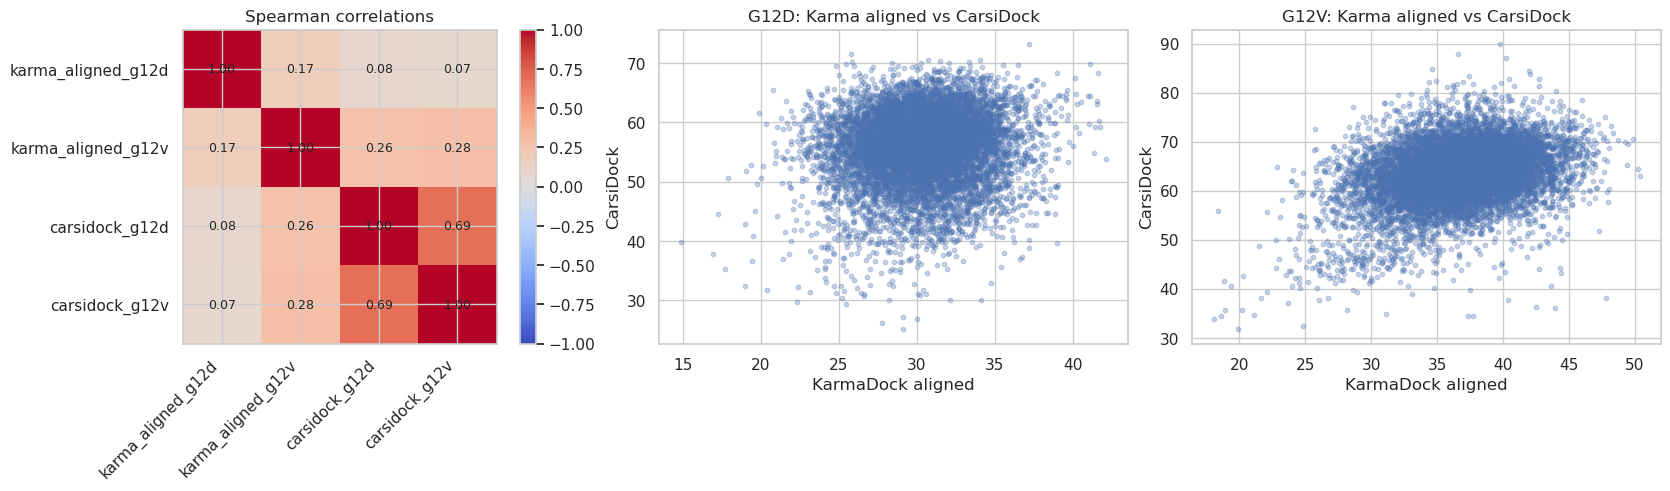

In [29]:

method_cols = ["karma_aligned_g12d", "karma_aligned_g12v", "carsidock_g12d", "carsidock_g12v"]
corr = combined[method_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), constrained_layout=True)

im = axes[0].imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
axes[0].set_xticks(range(len(method_cols)), method_cols, rotation=45, ha="right")
axes[0].set_yticks(range(len(method_cols)), method_cols)
axes[0].set_title("Spearman correlations")
for i in range(len(method_cols)):
    for j in range(len(method_cols)):
        axes[0].text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].scatter(combined["karma_aligned_g12d"], combined["carsidock_g12d"], s=10, alpha=0.3)
axes[1].set_title("G12D: Karma aligned vs CarsiDock")
axes[1].set_xlabel("KarmaDock aligned")
axes[1].set_ylabel("CarsiDock")

axes[2].scatter(combined["karma_aligned_g12v"], combined["carsidock_g12v"], s=10, alpha=0.3)
axes[2].set_title("G12V: Karma aligned vs CarsiDock")
axes[2].set_xlabel("KarmaDock aligned")
axes[2].set_ylabel("CarsiDock")

plt.show()


In [30]:

consensus_cols = [
    "sample_id", "inchikey", "karma_aligned_g12d", "karma_aligned_g12v", "karma_joint_min_aligned", "karma_rank_product",
    "carsidock_g12d", "carsidock_g12v", "carsidock_joint_min_score", "carsidock_worst_pct", "carsidock_rank_product",
    "cross_method_rank_product", "smiles",
]
consensus = (
    combined.dropna(subset=["karma_aligned_g12d", "karma_aligned_g12v", "carsidock_g12d", "carsidock_g12v"])
    .sort_values(["cross_method_rank_product", "carsidock_worst_pct", "karma_rank_product"], ascending=[True, True, True])
)

if EXPORT_TABLES:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    consensus[consensus_cols].to_csv(EXPORT_DIR / "karma_carsi_dual_target_consensus.csv", index=False)

consensus[consensus_cols].head(30)


,sample_id,inchikey,karma_aligned_g12d,karma_aligned_g12v,karma_joint_min_aligned,karma_rank_product,carsidock_g12d,carsidock_g12v,carsidock_joint_min_score,carsidock_worst_pct,carsidock_rank_product,cross_method_rank_product,smiles
5412,sample_6000,LRCWZTZKPDJWCB-UHFFFAOYSA-N,41.120708,40.464851,40.464851,122.118795,69.796393,72.596690,69.796393,0.046547,74.699398,20.904545,C#Cc1c(F)ccc2cc(O)cc(-c3nc(-c4cc(O)cc5ccc(F)c(...
9120,sample_2753,XIWOBRCBRLIRJL-UHFFFAOYSA-N,41.564251,43.662350,41.564251,42.953463,63.556326,74.097980,63.556326,0.071765,436.717300,25.298221,C#Cc1c(F)ccc2cc(O)cc(-c3nc(COCC(F)(F)F)c4c(N5C...
7394,sample_5127,DWZFZTSZJUPYLK-UHFFFAOYSA-N,32.054886,47.732471,32.054886,216.020832,69.974243,74.961591,69.974243,0.019419,44.045431,26.381812,C#Cc1c(F)ccc2cc(OC(=O)NCCOC)cc(-c3nc(OC)c4c(N5...
932,sample_5811,YPEQFVXJHZHLCD-UHFFFAOYSA-N,40.163689,43.022598,40.163689,97.118484,67.563692,75.041684,67.563692,0.019019,122.515305,28.195744,C#Cc1c(F)ccc2cc(O)cc(-c3nc(-c4cc(O)cc5ccc(F)c(...
5687,sample_1546,JCKVMOARVRKFDX-UHFFFAOYSA-N,39.006767,41.971977,39.006767,178.485294,68.376460,76.237505,68.376460,0.013113,78.466553,31.749016,C#Cc1c(F)ccc2cc(O)cc(-c3nc(-c4cncc(N)c4)c4c(N5...
1987,sample_3416,MSZXZTDMANOKMZ-UHFFFAOYSA-N,36.939468,49.836140,36.939468,22.315914,62.129982,70.501735,62.129982,0.124712,1121.811036,32.015621,C#Cc1c(F)ccc2cc(O)cc(-c3c4c(c5c(N6CC7CCC(C6)N7...
4561,sample_6184,UOFWWNBHZAXMKL-UHFFFAOYSA-N,41.599277,39.706429,39.706429,93.273791,68.337675,69.865908,68.337675,0.127427,247.192233,42.825226,C#Cc1c(F)ccc2cc(O)cc(-c3c(F)c4nc(OCC5(CN6CC7(C...
6799,sample_9925,UYAPJYWYTAYCRL-UHFFFAOYSA-N,34.070107,35.116623,34.070107,2555.471776,70.564629,77.205958,70.564629,0.009109,19.078784,50.249378,C#Cc1c(F)ccc2cc(O)cc(-c3nc4c5c(nc(OCC67CCCN6CC...
4864,sample_5581,PMDRQAZGSPNXBL-UHFFFAOYSA-N,40.226521,44.624695,40.226521,58.651513,64.872980,68.638298,64.872980,0.183483,820.189612,59.916609,C#Cc1c(F)ccc2cc(O)cc(-c3nc(OC)c4c(N5CC6CCC(C5)...
5202,sample_1728,UGNAARDUCKCHGV-UHFFFAOYSA-N,34.533485,44.225780,34.533485,459.499728,68.049417,77.363568,68.049417,0.008709,69.799713,60.241182,C#Cc1c(Cl)ccc2cc(O)cc(-c3c(C(C)C)cc4c(N5CC6CCC...


In [31]:

# Strict and relaxed cross-method overlap diagnostics.
for frac in [0.005, 0.01, 0.02, 0.05]:
    n = max(1, int(len(combined) * frac))
    karma_top = set(combined.nsmallest(n, "karma_rank_product")["sample_id"])
    carsi_top = set(combined.nsmallest(n, "carsidock_rank_product")["sample_id"])
    both = karma_top & carsi_top
    print(
        f"top {frac:.1%}: Karma={len(karma_top):4d}, Carsi={len(carsi_top):4d}, "
        f"overlap={len(both):4d}, jaccard={len(both)/len(karma_top | carsi_top):.3f}"
    )


top 0.5%: Karma=  49, Carsi=  49, overlap=   2, jaccard=0.021
top 1.0%: Karma=  99, Carsi=  99, overlap=   4, jaccard=0.021
top 2.0%: Karma= 199, Carsi= 199, overlap=  12, jaccard=0.031
top 5.0%: Karma= 499, Carsi= 499, overlap=  65, jaccard=0.070



## 高精度复打分候选选择建议

高精度方法更慢，所以不建议只拿一个总分榜的前 N。更稳妥的做法是分层抽样：

1. **共识优先**：KarmaDock 和 CarsiDock 都支持、且两个靶点都不错的分子，作为主候选。
2. **双靶点保守候选**：即使一个方法不极端靠前，但两个靶点都没有明显短板，也保留一部分。
3. **方法特异候选**：分别保留少量 KarmaDock 强、CarsiDock 强但另一方法一般的分子，用来避免错过方法偏好的化学型。
4. **结构多样性补充**：在高分候选池中补少量与已选结构不太相似的分子，避免最终列表被同一骨架占满。

下面的 `SELECT_N` 默认是 200，可以按高精度计算资源改成 50、100、500 等。默认不导出文件；如需导出，把 `EXPORT_SELECTION = True`。


In [32]:

SELECT_N = 200
EXPORT_SELECTION = False
SELECTION_EXPORT_PATH = Path("/home/aidd/CarsiDock/analysis_outputs/high_precision_candidates.csv")

# 分层比例可以按资源调整，总和不必严格等于 1，后面会自动补齐/去重。
SELECTION_BUCKETS = {
    "consensus": 0.45,
    "dual_target_conservative": 0.20,
    "karma_supported": 0.15,
    "carsi_supported": 0.15,
    "diversity_refill": 0.05,
}

selection_base = combined.dropna(subset=[
    "karma_aligned_g12d", "karma_aligned_g12v", "carsidock_g12d", "carsidock_g12v",
    "karma_rank_product", "carsidock_rank_product", "cross_method_rank_product",
]).copy()

# 结构重复时只保留一个 sample_id；高精度复打分通常没有必要重复同一个 InChIKey。
selection_base = selection_base.sort_values("cross_method_rank_product").drop_duplicates("inchikey", keep="first")
selection_base["karma_rank_pct"] = selection_base["karma_rank_product"].rank(method="min", pct=True, ascending=True)
selection_base["carsi_rank_pct"] = selection_base["carsidock_rank_product"].rank(method="min", pct=True, ascending=True)
selection_base["cross_method_pct"] = selection_base["cross_method_rank_product"].rank(method="min", pct=True, ascending=True)
selection_base["method_balance_gap"] = (selection_base["karma_rank_pct"] - selection_base["carsi_rank_pct"]).abs()
selection_base["joint_method_worst_pct"] = selection_base[["karma_rank_pct", "carsi_rank_pct"]].max(axis=1)

print(f"可用于候选选择的唯一结构数: {len(selection_base):,}")
selection_base[[
    "sample_id", "inchikey", "karma_rank_pct", "carsi_rank_pct", "cross_method_pct",
    "joint_method_worst_pct", "method_balance_gap"
]].head()


可用于候选选择的唯一结构数: 9,979


,sample_id,inchikey,karma_rank_pct,carsi_rank_pct,cross_method_pct,joint_method_worst_pct,method_balance_gap
5412,sample_6000,LRCWZTZKPDJWCB-UHFFFAOYSA-N,0.001904,0.002305,0.000100,0.002305,0.000401
9120,sample_2753,XIWOBRCBRLIRJL-UHFFFAOYSA-N,0.000200,0.031867,0.000200,0.031867,0.031666
7394,sample_5127,DWZFZTSZJUPYLK-UHFFFAOYSA-N,0.005812,0.001203,0.000301,0.005812,0.004610
932,sample_5811,YPEQFVXJHZHLCD-UHFFFAOYSA-N,0.001503,0.005311,0.000401,0.005311,0.003808
5687,sample_1546,JCKVMOARVRKFDX-UHFFFAOYSA-N,0.004209,0.002405,0.000501,0.004209,0.001804


In [33]:

def _target_count(frac):
    return max(1, int(round(SELECT_N * frac)))

def _take(df, count, label, selected_keys):
    if count <= 0 or df.empty:
        return []
    rows = []
    for _, row in df.iterrows():
        key = row["inchikey"]
        if key in selected_keys:
            continue
        item = row.copy()
        item["selection_bucket"] = label
        rows.append(item)
        selected_keys.add(key)
        if len(rows) >= count:
            break
    return rows

selected_keys = set()
selected_rows = []

# 1. 两种方法都支持的共识榜。
selected_rows += _take(
    selection_base.sort_values(["cross_method_rank_product", "joint_method_worst_pct", "method_balance_gap"]),
    _target_count(SELECTION_BUCKETS["consensus"]),
    "consensus",
    selected_keys,
)

# 2. 更强调两个靶点/两个方法都不能太差的保守榜。
selected_rows += _take(
    selection_base.sort_values(["joint_method_worst_pct", "cross_method_rank_product", "method_balance_gap"]),
    _target_count(SELECTION_BUCKETS["dual_target_conservative"]),
    "dual_target_conservative",
    selected_keys,
)

# 3. KarmaDock 支持较强的补充候选。
selected_rows += _take(
    selection_base.sort_values(["karma_rank_product", "carsidock_worst_pct", "cross_method_rank_product"]),
    _target_count(SELECTION_BUCKETS["karma_supported"]),
    "karma_supported",
    selected_keys,
)

# 4. CarsiDock 支持较强的补充候选。
selected_rows += _take(
    selection_base.sort_values(["carsidock_rank_product", "karma_rank_product", "cross_method_rank_product"]),
    _target_count(SELECTION_BUCKETS["carsi_supported"]),
    "carsi_supported",
    selected_keys,
)

# 5. 如果前面不足 SELECT_N，从高分联合候选池中继续补齐。
selected_rows += _take(
    selection_base.sort_values(["cross_method_pct", "joint_method_worst_pct", "method_balance_gap"]),
    SELECT_N - len(selected_rows),
    "refill_by_rank",
    selected_keys,
)

selection = pd.DataFrame(selected_rows).head(SELECT_N).reset_index(drop=True)
selection.insert(0, "selection_rank", np.arange(1, len(selection) + 1))

selection_cols = [
    "selection_rank", "selection_bucket", "sample_id", "inchikey",
    "karma_aligned_g12d", "karma_aligned_g12v", "karma_joint_min_aligned", "karma_rank_pct",
    "carsidock_g12d", "carsidock_g12v", "carsidock_joint_min_score", "carsi_rank_pct",
    "cross_method_pct", "joint_method_worst_pct", "method_balance_gap", "smiles",
]

if EXPORT_SELECTION:
    SELECTION_EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
    selection[selection_cols].to_csv(SELECTION_EXPORT_PATH, index=False)
    print(f"Exported: {SELECTION_EXPORT_PATH}")

print(selection["selection_bucket"].value_counts())
selection[selection_cols].head(40)


consensus                   90
dual_target_conservative    40
karma_supported             30
carsi_supported             30
refill_by_rank              10
Name: selection_bucket, dtype: int64


,selection_rank,selection_bucket,sample_id,inchikey,karma_aligned_g12d,karma_aligned_g12v,karma_joint_min_aligned,karma_rank_pct,carsidock_g12d,carsidock_g12v,carsidock_joint_min_score,carsi_rank_pct,cross_method_pct,joint_method_worst_pct,method_balance_gap,smiles
0,1,consensus,sample_6000,LRCWZTZKPDJWCB-UHFFFAOYSA-N,41.120708,40.464851,40.464851,0.001904,69.796393,72.596690,69.796393,0.002305,0.000100,0.002305,0.000401,C#Cc1c(F)ccc2cc(O)cc(-c3nc(-c4cc(O)cc5ccc(F)c(...
1,2,consensus,sample_2753,XIWOBRCBRLIRJL-UHFFFAOYSA-N,41.564251,43.662350,41.564251,0.000200,63.556326,74.097980,63.556326,0.031867,0.000200,0.031867,0.031666,C#Cc1c(F)ccc2cc(O)cc(-c3nc(COCC(F)(F)F)c4c(N5C...
2,3,consensus,sample_5127,DWZFZTSZJUPYLK-UHFFFAOYSA-N,32.054886,47.732471,32.054886,0.005812,69.974243,74.961591,69.974243,0.001203,0.000301,0.005812,0.004610,C#Cc1c(F)ccc2cc(OC(=O)NCCOC)cc(-c3nc(OC)c4c(N5...
3,4,consensus,sample_5811,YPEQFVXJHZHLCD-UHFFFAOYSA-N,40.163689,43.022598,40.163689,0.001503,67.563692,75.041684,67.563692,0.005311,0.000401,0.005311,0.003808,C#Cc1c(F)ccc2cc(O)cc(-c3nc(-c4cc(O)cc5ccc(F)c(...
4,5,consensus,sample_1546,JCKVMOARVRKFDX-UHFFFAOYSA-N,39.006767,41.971977,39.006767,0.004209,68.376460,76.237505,68.376460,0.002405,0.000501,0.004209,0.001804,C#Cc1c(F)ccc2cc(O)cc(-c3nc(-c4cncc(N)c4)c4c(N5...
5,6,consensus,sample_3416,MSZXZTDMANOKMZ-UHFFFAOYSA-N,36.939468,49.836140,36.939468,0.000100,62.129982,70.501735,62.129982,0.102515,0.000601,0.102515,0.102415,C#Cc1c(F)ccc2cc(O)cc(-c3c4c(c5c(N6CC7CCC(C6)N7...
6,7,consensus,sample_6184,UOFWWNBHZAXMKL-UHFFFAOYSA-N,41.599277,39.706429,39.706429,0.001403,68.337675,69.865908,68.337675,0.013027,0.000701,0.013027,0.011624,C#Cc1c(F)ccc2cc(O)cc(-c3c(F)c4nc(OCC5(CN6CC7(C...
7,8,consensus,sample_9925,UYAPJYWYTAYCRL-UHFFFAOYSA-N,34.070107,35.116623,34.070107,0.253031,70.564629,77.205958,70.564629,0.000100,0.000802,0.253031,0.252931,C#Cc1c(F)ccc2cc(O)cc(-c3nc4c5c(nc(OCC67CCCN6CC...
8,9,consensus,sample_5581,PMDRQAZGSPNXBL-UHFFFAOYSA-N,40.226521,44.624695,40.226521,0.000501,64.872980,68.638298,64.872980,0.071751,0.000902,0.071751,0.071250,C#Cc1c(F)ccc2cc(O)cc(-c3nc(OC)c4c(N5CC6CCC(C5)...
9,10,consensus,sample_1728,UGNAARDUCKCHGV-UHFFFAOYSA-N,34.533485,44.225780,34.533485,0.019140,68.049417,77.363568,68.049417,0.001904,0.001002,0.019140,0.017236,C#Cc1c(Cl)ccc2cc(O)cc(-c3c(C(C)C)cc4c(N5CC6CCC...



### 候选选择的可视化检查

理想情况下，被选中的分子应该集中在左下角：KarmaDock 和 CarsiDock 的联合排名都靠前。同时，我们希望不同分桶在图上有一定覆盖，而不是全被某一个方法或某一个靶点驱动。


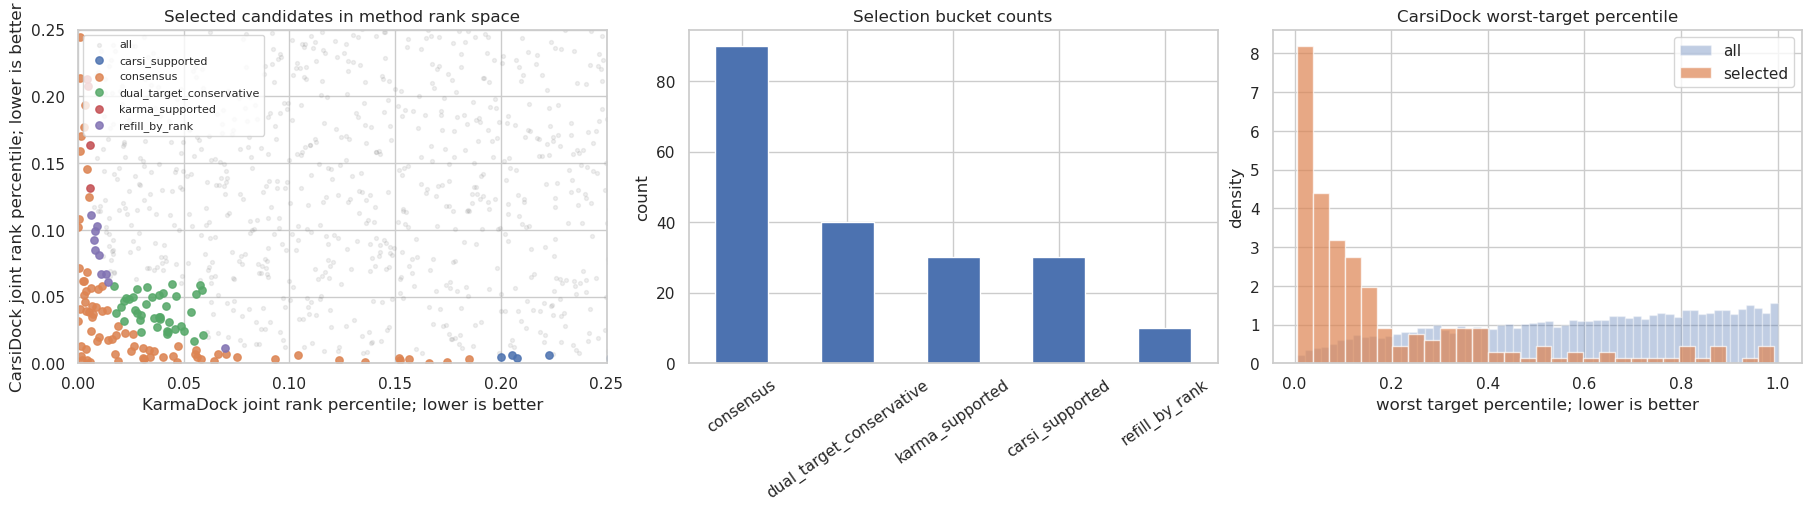

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# 1. Method consensus rank-space; lower-left is better.
axes[0].scatter(selection_base["karma_rank_pct"], selection_base["carsi_rank_pct"], s=8, alpha=0.12, color="gray", label="all")
for bucket, df in selection.groupby("selection_bucket"):
    axes[0].scatter(df["karma_rank_pct"], df["carsi_rank_pct"], s=28, alpha=0.85, label=bucket)
axes[0].set_xlabel("KarmaDock joint rank percentile; lower is better")
axes[0].set_ylabel("CarsiDock joint rank percentile; lower is better")
axes[0].set_title("Selected candidates in method rank space")
axes[0].set_xlim(0, min(0.25, selection_base["karma_rank_pct"].max()))
axes[0].set_ylim(0, min(0.25, selection_base["carsi_rank_pct"].max()))
axes[0].legend(fontsize=8)

# 2. Bucket counts.
selection["selection_bucket"].value_counts().reindex(selection["selection_bucket"].unique()).plot(kind="bar", ax=axes[1])
axes[1].set_title("Selection bucket counts")
axes[1].set_xlabel("")
axes[1].set_ylabel("count")
axes[1].tick_params(axis="x", rotation=35)

# 3. CarsiDock weaker-target percentile distribution; lower is better.
axes[2].hist(selection_base["carsidock_worst_pct"].dropna(), bins=60, alpha=0.35, density=True, label="all")
axes[2].hist(selection["carsidock_worst_pct"].dropna(), bins=30, alpha=0.70, density=True, label="selected")
axes[2].set_title("CarsiDock worst-target percentile")
axes[2].set_xlabel("worst target percentile; lower is better")
axes[2].set_ylabel("density")
axes[2].legend()

plt.show()


In [35]:

# 不同选择规模下的候选重叠和方法覆盖，用于决定 SELECT_N 是否足够。
size_rows = []
for n in [25, 50, 100, 200, 500, 1000]:
    n = min(n, len(selection_base))
    top_cross = set(selection_base.nsmallest(n, "cross_method_rank_product")["inchikey"])
    top_karma = set(selection_base.nsmallest(n, "karma_rank_product")["inchikey"])
    top_carsi = set(selection_base.nsmallest(n, "carsidock_rank_product")["inchikey"])
    size_rows.append({
        "N": n,
        "karma_carsi_overlap": len(top_karma & top_carsi),
        "cross_vs_karma_overlap": len(top_cross & top_karma),
        "cross_vs_carsi_overlap": len(top_cross & top_carsi),
        "karma_carsi_jaccard": len(top_karma & top_carsi) / len(top_karma | top_carsi),
    })
size_diagnostics = pd.DataFrame(size_rows)
size_diagnostics


,N,karma_carsi_overlap,cross_vs_karma_overlap,cross_vs_carsi_overlap,karma_carsi_jaccard
0,25,1,10,11,0.020408
1,50,2,22,20,0.020408
2,100,4,44,42,0.020408
3,200,12,96,86,0.030928
4,500,67,276,254,0.071811
5,1000,201,573,591,0.111729


## Glide SP 结果导入与重合度检查

这里同时读取同事提供的 Glide SP G12D 和 G12V 结果。Glide 的 `r_i_glide_gscore` 越负通常越好，所以每个靶点都按升序排名。

SDF 的分子名是数字 ID，按 `sample_数字` 映射回 sample10k；同时计算 InChIKey 作为结构层面的辅助检查。


In [36]:
from rdkit.Chem import inchi

GLIDE_SDFS = {
    "g12d": Path("/home/aidd/Downloads/glide-dock_SP_g12d_sampled_10k_with_id_pv1_remove_duplicates.sdf"),
    "g12v": Path("/home/aidd/Downloads/glide-dock_SP_g12v_sampled_10k_with_id_pv1_remove_duplicates.sdf"),
}

def read_glide_sdf(path, target):
    rows = []
    supplier = Chem.SDMolSupplier(str(path), removeHs=False, sanitize=False)
    for idx, mol in enumerate(supplier):
        if mol is None:
            continue
        name = mol.GetProp("_Name").strip() if mol.HasProp("_Name") else str(idx)
        sample_id = name if name.startswith("sample_") else f"sample_{name}" if name.isdigit() else name
        try:
            gscore = float(mol.GetProp("r_i_glide_gscore"))
        except Exception:
            gscore = np.nan
        try:
            mol_for_key = Chem.Mol(mol)
            Chem.SanitizeMol(mol_for_key)
            glide_inchikey = inchi.MolToInchiKey(Chem.RemoveHs(mol_for_key))
        except Exception:
            glide_inchikey = pd.NA
        rows.append({
            "sample_id": sample_id,
            "glide_name": name,
            "glide_target": target,
            "glide_gscore": gscore,
            "glide_inchikey": glide_inchikey,
        })

    df = pd.DataFrame(rows).dropna(subset=["glide_gscore"])
    df = df.sort_values("glide_gscore", ascending=True).reset_index(drop=True)
    df["glide_rank"] = np.arange(1, len(df) + 1)
    df["glide_pct"] = df["glide_rank"] / max(len(df), 1)
    return df

glide_raw = pd.concat(
    [read_glide_sdf(path, target) for target, path in GLIDE_SDFS.items()],
    ignore_index=True,
)

for target, df in glide_raw.groupby("glide_target"):
    print(f"Glide {target.upper()}: molecules={len(df):,}, unique sample IDs={df['sample_id'].nunique():,}, unique InChIKeys={df['glide_inchikey'].nunique(dropna=True):,}")

glide_wide = None
for target, df in glide_raw.groupby("glide_target"):
    part = df[["sample_id", "glide_gscore", "glide_rank", "glide_pct", "glide_inchikey"]].rename(columns={
        "glide_gscore": f"glide_gscore_{target}",
        "glide_rank": f"glide_rank_{target}",
        "glide_pct": f"glide_pct_{target}",
        "glide_inchikey": f"glide_inchikey_{target}",
    })
    glide_wide = part if glide_wide is None else glide_wide.merge(part, on="sample_id", how="outer")

glide_wide["glide_rank_product"] = np.sqrt(glide_wide["glide_rank_g12d"] * glide_wide["glide_rank_g12v"])
glide_wide["glide_worst_rank"] = glide_wide[["glide_rank_g12d", "glide_rank_g12v"]].max(axis=1)
glide_wide["glide_mean_rank"] = glide_wide[["glide_rank_g12d", "glide_rank_g12v"]].mean(axis=1)
glide_wide["glide_joint_gscore_sum"] = glide_wide[["glide_gscore_g12d", "glide_gscore_g12v"]].sum(axis=1)

print(f"Glide structures with both targets: {glide_wide.dropna(subset=['glide_rank_g12d', 'glide_rank_g12v']).shape[0]:,}")
display(glide_wide.sort_values(["glide_rank_product", "glide_worst_rank"]).head(10))


Glide G12D: molecules=9,688, unique sample IDs=9,688, unique InChIKeys=9,682
Glide G12V: molecules=9,681, unique sample IDs=9,681, unique InChIKeys=9,676
Glide structures with both targets: 9,659


,sample_id,glide_gscore_g12d,glide_rank_g12d,glide_pct_g12d,glide_inchikey_g12d,glide_gscore_g12v,glide_rank_g12v,glide_pct_g12v,glide_inchikey_g12v,glide_rank_product,glide_worst_rank,glide_mean_rank,glide_joint_gscore_sum
29,sample_3543,-14.129560,30.0,0.003097,YOXGEBIOPKGLFA-NGQKNNJMSA-O,-14.103089,4.0,0.000413,YOXGEBIOPKGLFA-NGQKNNJMSA-O,10.954451,30.0,17.0,-28.232649
15,sample_7961,-14.294271,16.0,0.001652,IXTQASRDKSLVEG-JTCMQYHLSA-O,-13.697809,24.0,0.002479,IXTQASRDKSLVEG-JTCMQYHLSA-O,19.595918,24.0,20.0,-27.992079
22,sample_5802,-14.210908,23.0,0.002374,LFAXULLYSRPAOX-VDCWUDRBSA-O,-13.734251,18.0,0.001859,LFAXULLYSRPAOX-VDCWUDRBSA-O,20.346990,23.0,20.5,-27.945159
53,sample_9700,-13.968964,54.0,0.005574,UCKPMQBZAJWCJK-VSJLXWSYSA-O,-13.950662,9.0,0.000930,UCKPMQBZAJWCJK-VSJLXWSYSA-O,22.045408,54.0,31.5,-27.919626
45,sample_7528,-14.003977,46.0,0.004748,XTNVQWJCNXHKPW-SRUMYIKXSA-O,-13.772339,14.0,0.001446,XTNVQWJCNXHKPW-SRUMYIKXSA-O,25.377155,46.0,30.0,-27.776316
16,sample_4139,-14.282838,17.0,0.001755,JOUALSSXKCLKHB-QJUDAHSESA-P,-13.466002,52.0,0.005371,JOUALSSXKCLKHB-QJUDAHSESA-O,29.732137,52.0,34.5,-27.748840
37,sample_2805,-14.076670,38.0,0.003922,VPUBFEWLYKLMDZ-VPEVRTBJSA-P,-13.685957,25.0,0.002582,VPUBFEWLYKLMDZ-VPEVRTBJSA-P,30.822070,38.0,31.5,-27.762627
118,sample_217,-13.820109,119.0,0.012283,FCCDBHJFPDDZEX-FQWSOJTLSA-O,-13.954017,8.0,0.000826,FCCDBHJFPDDZEX-FQWSOJTLSA-O,30.854497,119.0,63.5,-27.774127
11,sample_2966,-14.313734,12.0,0.001239,QYLFLEBSPJOIMV-NLGDRYJYSA-O,-13.319928,88.0,0.009090,QYLFLEBSPJOIMV-NLGDRYJYSA-O,32.496154,88.0,50.0,-27.633662
48,sample_1428,-13.985485,49.0,0.005058,ZPFCAFOINSBKLM-GSTQUKTASA-O,-13.704100,23.0,0.002376,ZPFCAFOINSBKLM-GSTQUKTASA-O,33.570821,49.0,36.0,-27.689585


### Glide 与 KarmaDock/CarsiDock 的映射

这里按 `sample_id` 把 Glide G12D/G12V 联合表和已有 `combined` 表合并。Glide 分支单独排序；KarmaDock/CarsiDock 的列只用于查看这些 Glide 候选是否也被其他方法支持。


In [37]:
glide_compare = glide_wide.merge(
    combined,
    on="sample_id",
    how="left",
    suffixes=("_glide", ""),
)

summary = pd.DataFrame({
    "metric": [
        "Glide G12D molecules",
        "Glide G12V molecules",
        "Glide molecules with both targets",
        "matched to combined table",
        "matched KarmaDock ranks",
        "matched CarsiDock ranks",
    ],
    "count": [
        glide_raw.loc[glide_raw["glide_target"] == "g12d", "sample_id"].nunique(),
        glide_raw.loc[glide_raw["glide_target"] == "g12v", "sample_id"].nunique(),
        glide_wide.dropna(subset=["glide_rank_g12d", "glide_rank_g12v"]).shape[0],
        glide_compare[["karma_rank_product", "carsidock_rank_product"]].notna().any(axis=1).sum(),
        glide_compare["karma_rank_product"].notna().sum(),
        glide_compare["carsidock_rank_product"].notna().sum(),
    ],
})
display(summary)

display(
    glide_compare[[
        "sample_id", "glide_gscore_g12d", "glide_gscore_g12v", "glide_rank_g12d", "glide_rank_g12v",
        "glide_rank_product", "glide_worst_rank", "karma_rank_product", "carsidock_rank_product",
    ]].sort_values(["glide_rank_product", "glide_worst_rank"]).head(20)
)


,metric,count
0,Glide G12D molecules,9688
1,Glide G12V molecules,9681
2,Glide molecules with both targets,9659
3,matched to combined table,9701
4,matched KarmaDock ranks,9697
5,matched CarsiDock ranks,9700


,sample_id,glide_gscore_g12d,glide_gscore_g12v,glide_rank_g12d,glide_rank_g12v,glide_rank_product,glide_worst_rank,karma_rank_product,carsidock_rank_product
29,sample_3543,-14.129560,-14.103089,30.0,4.0,10.954451,30.0,6829.614338,8812.358935
15,sample_7961,-14.294271,-13.697809,16.0,24.0,19.595918,24.0,3512.555480,7056.469372
22,sample_5802,-14.210908,-13.734251,23.0,18.0,20.346990,23.0,1750.625031,5400.806606
53,sample_9700,-13.968964,-13.950662,54.0,9.0,22.045408,54.0,5336.764938,8239.999454
45,sample_7528,-14.003977,-13.772339,46.0,14.0,25.377155,46.0,1227.346732,6514.725244
16,sample_4139,-14.282838,-13.466002,17.0,52.0,29.732137,52.0,6657.833882,2219.681734
37,sample_2805,-14.076670,-13.685957,38.0,25.0,30.822070,38.0,4490.044989,3094.987076
118,sample_217,-13.820109,-13.954017,119.0,8.0,30.854497,119.0,4395.793444,6770.704247
11,sample_2966,-14.313734,-13.319928,12.0,88.0,32.496154,88.0,2325.921108,3115.976893
48,sample_1428,-13.985485,-13.704100,49.0,23.0,33.570821,49.0,2960.653982,7738.552578


### Glide Top 榜与已有方法的重合度

这里的 Glide Top-N 使用 G12D/G12V 的联合 Glide 排名，而不是只看某一个靶点。重合度低并不一定说明 Glide 结果无价值；它可能反映了打分函数、构象处理和蛋白准备方式的差异。


,top_n,glide_top,karma_top,carsi_top,glide_and_karma,glide_and_carsi,karma_and_carsi,all_three
0,25,25,25,25,0,0,1,0
1,50,50,50,50,1,0,2,0
2,100,100,100,100,4,0,4,0
3,200,200,200,200,10,2,12,0
4,500,500,500,500,36,19,66,1
5,1000,1000,1000,1000,113,89,201,16


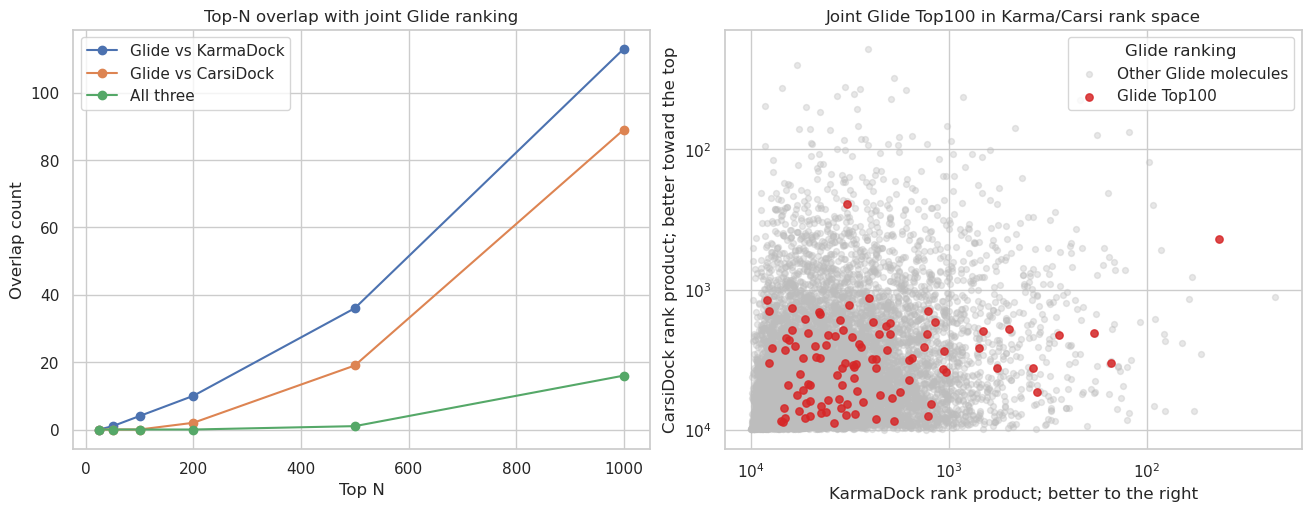

In [38]:
def top_sample_set(df, rank_col, n):
    return set(df.sort_values(rank_col).head(min(n, len(df)))["sample_id"].dropna())

method_rank_table = combined[[
    "sample_id", "karma_rank_product", "carsidock_rank_product"
]].dropna(subset=["sample_id"]).copy()
method_rank_table["sample_id"] = method_rank_table["sample_id"].astype(str)

karma_rank_table = method_rank_table.dropna(subset=["karma_rank_product"]).copy()
carsi_rank_table = method_rank_table.dropna(subset=["carsidock_rank_product"]).copy()
glide_rank_table = glide_compare.dropna(subset=["glide_rank_product"]).copy()

overlap_rows = []
for n in [25, 50, 100, 200, 500, 1000]:
    glide_top = top_sample_set(glide_rank_table, "glide_rank_product", n)
    karma_top = top_sample_set(karma_rank_table, "karma_rank_product", n)
    carsi_top = top_sample_set(carsi_rank_table, "carsidock_rank_product", n)
    overlap_rows.append({
        "top_n": n,
        "glide_top": len(glide_top),
        "karma_top": len(karma_top),
        "carsi_top": len(carsi_top),
        "glide_and_karma": len(glide_top & karma_top),
        "glide_and_carsi": len(glide_top & carsi_top),
        "karma_and_carsi": len(karma_top & carsi_top),
        "all_three": len(glide_top & karma_top & carsi_top),
    })

glide_overlap = pd.DataFrame(overlap_rows)
display(glide_overlap)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
axes[0].plot(glide_overlap["top_n"], glide_overlap["glide_and_karma"], marker="o", label="Glide vs KarmaDock")
axes[0].plot(glide_overlap["top_n"], glide_overlap["glide_and_carsi"], marker="o", label="Glide vs CarsiDock")
axes[0].plot(glide_overlap["top_n"], glide_overlap["all_three"], marker="o", label="All three")
axes[0].set_xlabel("Top N")
axes[0].set_ylabel("Overlap count")
axes[0].set_title("Top-N overlap with joint Glide ranking")
axes[0].legend()

plot_df = glide_compare.dropna(subset=["karma_rank_product", "carsidock_rank_product", "glide_rank_product"]).copy()
plot_df["is_glide_top100"] = plot_df["glide_rank_product"].rank(method="min") <= 100
background = plot_df[~plot_df["is_glide_top100"]]
highlight = plot_df[plot_df["is_glide_top100"]]
axes[1].scatter(
    background["karma_rank_product"],
    background["carsidock_rank_product"],
    s=18, alpha=0.35, color="#bdbdbd", label="Other Glide molecules",
)
axes[1].scatter(
    highlight["karma_rank_product"],
    highlight["carsidock_rank_product"],
    s=28, alpha=0.85, color="#d62728", label="Glide Top100",
)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].invert_xaxis()
axes[1].invert_yaxis()
axes[1].set_xlabel("KarmaDock rank product; better to the right")
axes[1].set_ylabel("CarsiDock rank product; better toward the top")
axes[1].set_title("Joint Glide Top100 in Karma/Carsi rank space")
axes[1].legend(title="Glide ranking")
plt.show()


### 给高精度复打分的 Glide 候选

Glide 这一路仍然建议单独保留，不和 KarmaDock/CarsiDock 强行取交集。现在有 G12D 和 G12V 两个 Glide 结果后，默认用 Glide 自己的两个靶点联合排名选择前 100 个分子。

表中同时保留 KarmaDock/CarsiDock 的支持情况，方便后续人工检查。默认不单独导出 Glide 分支文件。


In [39]:
GLIDE_SELECT_N = 100
EXPORT_GLIDE_SELECTION = False
GLIDE_SELECTION_EXPORT_PATH = Path("/home/aidd/CarsiDock/analysis_outputs/glide_joint_top100_high_precision_candidates.csv")

glide_selection = glide_compare.dropna(subset=["glide_rank_product"]).copy()
glide_selection["glide_supported_by_karma_top5pct"] = glide_selection["karma_rank_product"] <= max(1, int(len(karma_rank_table) * 0.05))
glide_selection["glide_supported_by_carsi_top5pct"] = glide_selection["carsidock_rank_product"] <= max(1, int(len(carsi_rank_table) * 0.05))
glide_selection["support_count"] = (
    glide_selection["glide_supported_by_karma_top5pct"].fillna(False).astype(int)
    + glide_selection["glide_supported_by_carsi_top5pct"].fillna(False).astype(int)
)

glide_selection = glide_selection.sort_values(
    ["glide_rank_product", "glide_worst_rank", "glide_joint_gscore_sum"],
    ascending=[True, True, True],
).head(GLIDE_SELECT_N).reset_index(drop=True)
glide_selection["selection_rank"] = np.arange(1, len(glide_selection) + 1)

cols = [
    "selection_rank", "sample_id", "glide_gscore_g12d", "glide_gscore_g12v",
    "glide_rank_g12d", "glide_rank_g12v", "glide_rank_product", "glide_worst_rank", "support_count",
    "karma_rank_product", "carsidock_rank_product", "smiles",
]
display(glide_selection[cols].head(30))
print(glide_selection["support_count"].value_counts().sort_index())

if EXPORT_GLIDE_SELECTION:
    GLIDE_SELECTION_EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
    glide_selection.to_csv(GLIDE_SELECTION_EXPORT_PATH, index=False)
    print(f"wrote {GLIDE_SELECTION_EXPORT_PATH}")
else:
    print("EXPORT_GLIDE_SELECTION is False; no CSV file written.")


,selection_rank,sample_id,glide_gscore_g12d,glide_gscore_g12v,glide_rank_g12d,glide_rank_g12v,glide_rank_product,glide_worst_rank,support_count,karma_rank_product,carsidock_rank_product,smiles
0,1,sample_3543,-14.129560,-14.103089,30.0,4.0,10.954451,30.0,0,6829.614338,8812.358935,CCc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CC6C(=O)NC(=O)C...
1,2,sample_7961,-14.294271,-13.697809,16.0,24.0,19.595918,24.0,0,3512.555480,7056.469372,CCc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CCCC(C)(O)C5)nc...
2,3,sample_5802,-14.210908,-13.734251,23.0,18.0,20.346990,23.0,0,1750.625031,5400.806606,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CC6CCC(C5)N6)n...
3,4,sample_9700,-13.968964,-13.950662,54.0,9.0,22.045408,54.0,0,5336.764938,8239.999454,CCc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CCCCC(C)(O)C5)n...
4,5,sample_7528,-14.003977,-13.772339,46.0,14.0,25.377155,46.0,0,1227.346732,6514.725244,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CCCC(C)(O)C5)n...
5,6,sample_4139,-14.282838,-13.466002,17.0,52.0,29.732137,52.0,0,6657.833882,2219.681734,CCc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CC6CCC(C5)N6)nc...
6,7,sample_2805,-14.076670,-13.685957,38.0,25.0,30.822070,38.0,0,4490.044989,3094.987076,Oc1cc(-c2ncc3c(N4CC5CCC(C4)N5)nc(OCC45CC(F)CN4...
7,8,sample_217,-13.820109,-13.954017,119.0,8.0,30.854497,119.0,0,4395.793444,6770.704247,CCc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CCC(O)C(O)C5)nc...
8,9,sample_2966,-14.313734,-13.319928,12.0,88.0,32.496154,88.0,0,2325.921108,3115.976893,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CCCC(O)C5)nc(O...
9,10,sample_1428,-13.985485,-13.704100,49.0,23.0,33.570821,49.0,0,2960.653982,7738.552578,CCc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CCCC(C)(O)C5)nc...


0    92
1     7
2     1
Name: support_count, dtype: int64
EXPORT_GLIDE_SELECTION is False; no CSV file written.


### 最终复打分候选池汇总

这里把 KarmaDock+CarsiDock 的联合候选和 Glide 联合候选合并，并按 `sample_id` 去重。这个表用于估计最终需要送入高精度复打分的分子数量。


In [40]:
EXPORT_FINAL_HIGH_PRECISION_POOL = True
FINAL_POOL_EXPORT_PATH = Path("/home/aidd/CarsiDock/analysis_outputs/final_high_precision_pool.csv")

kc_pool = selection.copy()
kc_pool["source_pool"] = "karma_carsi"
kc_pool["source_rank"] = kc_pool["selection_rank"]

glide_pool = glide_selection.copy()
glide_pool["source_pool"] = "glide"
glide_pool["source_rank"] = glide_pool["selection_rank"]

final_pool = pd.concat([
    kc_pool[["sample_id", "source_pool", "source_rank", "inchikey", "smiles"]],
    glide_pool[["sample_id", "source_pool", "source_rank", "inchikey", "smiles"]],
], ignore_index=True)

final_pool_summary = (
    final_pool.groupby("sample_id", as_index=False)
    .agg(
        source_pools=("source_pool", lambda x: ",".join(sorted(set(x)))),
        best_source_rank=("source_rank", "min"),
        inchikey=("inchikey", "first"),
        smiles=("smiles", "first"),
    )
    .sort_values(["source_pools", "best_source_rank"])
    .reset_index(drop=True)
)

print(f"KarmaDock+CarsiDock pool: {len(kc_pool):,}")
print(f"Glide pool: {len(glide_pool):,}")
print(f"Final deduplicated pool: {len(final_pool_summary):,}")
display(final_pool_summary.head(30))

if EXPORT_FINAL_HIGH_PRECISION_POOL:
    FINAL_POOL_EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
    final_pool_summary.to_csv(FINAL_POOL_EXPORT_PATH, index=False)
    print(f"wrote {FINAL_POOL_EXPORT_PATH}")
else:
    print("EXPORT_FINAL_HIGH_PRECISION_POOL is False; no CSV file written.")


KarmaDock+CarsiDock pool: 200
Glide pool: 100
Final deduplicated pool: 297


,sample_id,source_pools,best_source_rank,inchikey,smiles
0,sample_3543,glide,1,YOXGEBIOPKGLFA-UHFFFAOYSA-N,CCc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CC6C(=O)NC(=O)C...
1,sample_7961,glide,2,IXTQASRDKSLVEG-UHFFFAOYSA-N,CCc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CCCC(C)(O)C5)nc...
2,sample_5802,glide,3,LFAXULLYSRPAOX-UHFFFAOYSA-N,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CC6CCC(C5)N6)n...
3,sample_9700,glide,4,UCKPMQBZAJWCJK-UHFFFAOYSA-N,CCc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CCCCC(C)(O)C5)n...
4,sample_7528,glide,5,XTNVQWJCNXHKPW-UHFFFAOYSA-N,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CCCC(C)(O)C5)n...
5,sample_4139,glide,6,JOUALSSXKCLKHB-UHFFFAOYSA-N,CCc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CC6CCC(C5)N6)nc...
6,sample_2805,glide,7,VPUBFEWLYKLMDZ-UHFFFAOYSA-N,Oc1cc(-c2ncc3c(N4CC5CCC(C4)N5)nc(OCC45CC(F)CN4...
7,sample_217,glide,8,FCCDBHJFPDDZEX-UHFFFAOYSA-N,CCc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CCC(O)C(O)C5)nc...
8,sample_2966,glide,9,QYLFLEBSPJOIMV-UHFFFAOYSA-N,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CCCC(O)C5)nc(O...
9,sample_1428,glide,10,ZPFCAFOINSBKLM-UHFFFAOYSA-N,CCc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CCCC(C)(O)C5)nc...


wrote /home/aidd/CarsiDock/analysis_outputs/final_high_precision_pool.csv
